# 01 ? Acoustic Feature Quality Control

This notebook inspects the outputs of the stage-2 acoustic extraction pipeline for the French IDS project.

**Input files**
- `outputs/french_vowels_acoustic_features.csv`
- `outputs/acoustic_feature_log.csv`
- `outputs/formant_ceilings.csv`

**Main QC questions**
1. Did acoustic extraction work?
2. Which rows failed and why?
3. Are duration, pitch, pitch range, and formant values reasonable?
4. Are IDS and ADS distributions different?
5. Are vowel formant spaces sensible?
6. Are central-frame and mean formants consistent?
7. Which speakers, vowels, files, activities, or registers need checking?
8. Are there suspicious acoustic outliers?

## 1. Setup and imports

Set plotting defaults, locate the repository outputs folder, and define reusable helper functions for summaries, tables, and plots.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 200)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

if (Path.cwd() / 'outputs').exists():
    ROOT = Path.cwd()
elif (Path.cwd().parent / 'outputs').exists():
    ROOT = Path.cwd().parent
else:
    raise FileNotFoundError('Could not locate the repository outputs directory from the current notebook working directory.')

OUTPUTS_DIR = ROOT / 'outputs'
QC_DIR = OUTPUTS_DIR / 'qc'
PLOTS_DIR = QC_DIR / 'plots'
QC_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_CSV = OUTPUTS_DIR / 'french_vowels_acoustic_features.csv'
LOG_CSV = OUTPUTS_DIR / 'acoustic_feature_log.csv'
CEILINGS_CSV = OUTPUTS_DIR / 'formant_ceilings.csv'

METADATA_COLS = [
    'speakerid', 'session', 'activity', 'time', 'word', 'vowel', 'register',
    'start_sec', 'duration_sec', 'duration_ms'
]
PITCH_COLS = ['mean_pitch', 'min_pitch', 'max_pitch', 'pitch_range']
FORMANT_COLS = [
    'mean_F1', 'mean_F2', 'mean_F3', 'mean_F4',
    'central_F1', 'central_F2', 'central_F3', 'central_F4'
]
ACOUSTIC_COLS = PITCH_COLS + ['formant_ceiling'] + FORMANT_COLS
STATUS_COLS = ['feature_status', 'feature_error']
SESSION_ORDER = ['4m', '8m', '12m']
REGISTER_ORDER = ['IDS', 'ADS']
ACTIVITY_ORDER = ['bath', 'meal', 'play']


def require_columns(df: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f'{name} is missing required columns: {missing}')
    print(f'{name}: all required columns present ({len(required)} columns checked).')


def numeric_summary(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors='coerce')
    valid = values.dropna()
    if valid.empty:
        return pd.Series({
            'n_non_missing': 0,
            'n_missing': int(values.isna().sum()),
            'missing_pct': 100.0,
            'mean': np.nan,
            'median': np.nan,
            'std': np.nan,
            'min': np.nan,
            'p05': np.nan,
            'p25': np.nan,
            'p75': np.nan,
            'p95': np.nan,
            'max': np.nan,
        })
    return pd.Series({
        'n_non_missing': int(valid.size),
        'n_missing': int(values.isna().sum()),
        'missing_pct': float(values.isna().mean() * 100),
        'mean': float(valid.mean()),
        'median': float(valid.median()),
        'std': float(valid.std()),
        'min': float(valid.min()),
        'p05': float(valid.quantile(0.05)),
        'p25': float(valid.quantile(0.25)),
        'p75': float(valid.quantile(0.75)),
        'p95': float(valid.quantile(0.95)),
        'max': float(valid.max()),
    })


def grouped_numeric_summary(df: pd.DataFrame, group_cols, value_col: str) -> pd.DataFrame:
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    grouped = (
        df.groupby(group_cols, dropna=False)[value_col]
        .apply(lambda s: numeric_summary(s))
        .unstack()
        .reset_index()
    )
    return grouped


def save_table(df: pd.DataFrame, filename: str) -> None:
    path = QC_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved table -> {path}')


def finish_plot(fig: plt.Figure, filename: str) -> None:
    path = PLOTS_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved plot -> {path}')


def top_categories(series: pd.Series, max_n: int = 12) -> list[str]:
    return series.fillna('(missing)').astype(str).value_counts().head(max_n).index.tolist()


def sample_for_scatter(df: pd.DataFrame, max_rows: int = 5000, random_state: int = 42) -> pd.DataFrame:
    if len(df) <= max_rows:
        return df
    return df.sample(n=max_rows, random_state=random_state)


def plot_count(series: pd.Series, title: str, filename: str, max_n: int | None = None, rotate: int = 45) -> None:
    plot_series = series.fillna('(missing)').astype(str)
    counts = plot_series.value_counts()
    if max_n is not None:
        counts = counts.head(max_n)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=rotate)
    finish_plot(fig, filename)


def plot_hist(df: pd.DataFrame, column: str, title: str, filename: str, bins: int = 40) -> None:
    plot_df = df[[column]].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(plot_df[column], bins=bins, edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    finish_plot(fig, filename)


def plot_box(df: pd.DataFrame, x: str, y: str, title: str, filename: str, order=None, rotate: int = 45) -> None:
    plot_df = df[[x, y]].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=plot_df, x=x, y=y, order=order, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=rotate)
    finish_plot(fig, filename)


def plot_scatter(df: pd.DataFrame, x: str, y: str, title: str, filename: str, hue: str | None = None) -> None:
    plot_cols = [x, y] + ([hue] if hue else [])
    plot_df = sample_for_scatter(df[plot_cols].dropna())
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x=x, y=y, hue=hue, ax=ax, alpha=0.35, s=25)
    ax.set_title(title)
    finish_plot(fig, filename)


def plot_vowel_space(df: pd.DataFrame, f1_col: str, f2_col: str, title: str, filename: str, hue: str = 'vowel') -> None:
    plot_df = sample_for_scatter(df[[f1_col, f2_col, hue]].dropna())
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x=f2_col, y=f1_col, hue=hue, ax=ax, alpha=0.45, s=28)
    ax.set_title(title)
    ax.set_xlabel(f2_col)
    ax.set_ylabel(f1_col)
    ax.invert_xaxis()
    ax.invert_yaxis()
    finish_plot(fig, filename)


## 2. Load acoustic output files

Load the three stage-2 output files, print shapes and columns, inspect the first few rows, and confirm that the expected metadata, acoustic, and status columns exist.

In [2]:
features_df = pd.read_csv(FEATURES_CSV)
log_df = pd.read_csv(LOG_CSV)
ceilings_df = pd.read_csv(CEILINGS_CSV)

for col in ['start_sec', 'duration_sec', 'duration_ms'] + PITCH_COLS + FORMANT_COLS + ['formant_ceiling']:
    if col in features_df.columns:
        features_df[col] = pd.to_numeric(features_df[col], errors='coerce')
if 'formant_ceiling' in log_df.columns:
    log_df['formant_ceiling'] = pd.to_numeric(log_df['formant_ceiling'], errors='coerce')
if 'formant_ceiling' in ceilings_df.columns:
    ceilings_df['formant_ceiling'] = pd.to_numeric(ceilings_df['formant_ceiling'], errors='coerce')
if 'n_tokens' in ceilings_df.columns:
    ceilings_df['n_tokens'] = pd.to_numeric(ceilings_df['n_tokens'], errors='coerce')

if 'session' in features_df.columns:
    features_df['session'] = pd.Categorical(features_df['session'], categories=SESSION_ORDER, ordered=True)
if 'register' in features_df.columns:
    features_df['register'] = pd.Categorical(features_df['register'], categories=REGISTER_ORDER, ordered=True)
if 'activity' in features_df.columns:
    features_df['activity'] = pd.Categorical(features_df['activity'], categories=ACTIVITY_ORDER, ordered=True)

require_columns(features_df, METADATA_COLS + ACOUSTIC_COLS + STATUS_COLS, 'features_df')
require_columns(log_df, ['row_index', 'speakerid', 'vowel', 'audio_file', 'start_sec', 'duration_sec', 'feature_status', 'feature_error', 'formant_ceiling'], 'log_df')
require_columns(ceilings_df, ['speakerid', 'vowel', 'formant_ceiling', 'n_tokens', 'optimization_status'], 'ceilings_df')

print('features_df shape:', features_df.shape)
print('log_df shape:', log_df.shape)
print('ceilings_df shape:', ceilings_df.shape)
print('\nfeatures_df columns:')
print(features_df.columns.tolist())
print('\nlog_df columns:')
print(log_df.columns.tolist())
print('\nceilings_df columns:')
print(ceilings_df.columns.tolist())

print('\nfeatures_df head:')
print(features_df.head())
print('\nlog_df head:')
print(log_df.head())
print('\nceilings_df head:')
print(ceilings_df.head())

qc_df = features_df.reset_index().rename(columns={'index': 'row_index'})
log_merge_cols = ['row_index'] + [c for c in ['audio_file', 'feature_error_detail'] if c in log_df.columns]
qc_df = qc_df.merge(log_df[log_merge_cols].drop_duplicates('row_index'), on='row_index', how='left', suffixes=('', '_log'))
if 'feature_error_detail_log' in qc_df.columns:
    qc_df['feature_error_detail'] = qc_df['feature_error_detail'].fillna(qc_df['feature_error_detail_log'])
    qc_df = qc_df.drop(columns=['feature_error_detail_log'])
if 'audio_file' not in qc_df.columns:
    qc_df['audio_file'] = ''
qc_df['audio_file'] = qc_df['audio_file'].fillna('')
qc_df['feature_error'] = qc_df['feature_error'].fillna('')
qc_df['feature_error_detail'] = qc_df['feature_error_detail'].fillna('')
success_df = qc_df[qc_df['feature_status'].eq('success')].copy()
failed_df = qc_df[qc_df['feature_status'].eq('failed')].copy()


features_df: all required columns present (25 columns checked).
log_df: all required columns present (9 columns checked).
ceilings_df: all required columns present (5 columns checked).
features_df shape: (21341, 26)
log_df shape: (21341, 10)
ceilings_df shape: (422, 6)

features_df columns:
['speakerid', 'session', 'activity', 'time', 'word', 'vowel', 'register', 'start_sec', 'duration_sec', 'duration_ms', 'mean_pitch', 'min_pitch', 'max_pitch', 'pitch_range', 'mean_F1', 'mean_F2', 'mean_F3', 'mean_F4', 'central_F1', 'central_F2', 'central_F3', 'central_F4', 'feature_status', 'feature_error', 'feature_error_detail', 'formant_ceiling']

log_df columns:
['row_index', 'speakerid', 'vowel', 'audio_file', 'start_sec', 'duration_sec', 'feature_status', 'feature_error', 'feature_error_detail', 'formant_ceiling']

ceilings_df columns:
['speakerid', 'vowel', 'formant_ceiling', 'n_tokens', 'optimization_status', 'optimizer_version']

features_df head:
  speakerid session activity  time       wor

## 3. Basic extraction summary

Summarize how many rows succeeded or failed, compute simple percentages, inspect error labels, and save the main extraction summary tables.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\extraction_summary.csv
Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\error_summary.csv
               metric    value
0          total_rows  21341.0
1     successful_rows  21106.0
2         failed_rows    235.0
3  success_percentage     98.9
4   failed_percentage      1.1

feature_status counts:
  feature_status  n_rows
0        success   21106
1         failed     235

feature_error counts:
           feature_error  n_rows
0                 (none)   21106
1  invalid_time_interval     118
2     pitch_not_detected     117


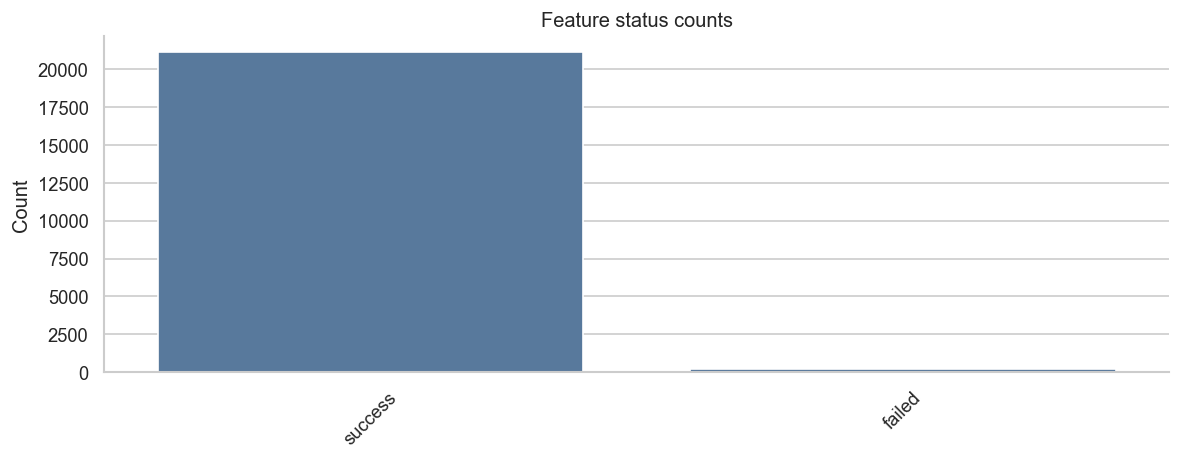

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\feature_status_counts.png


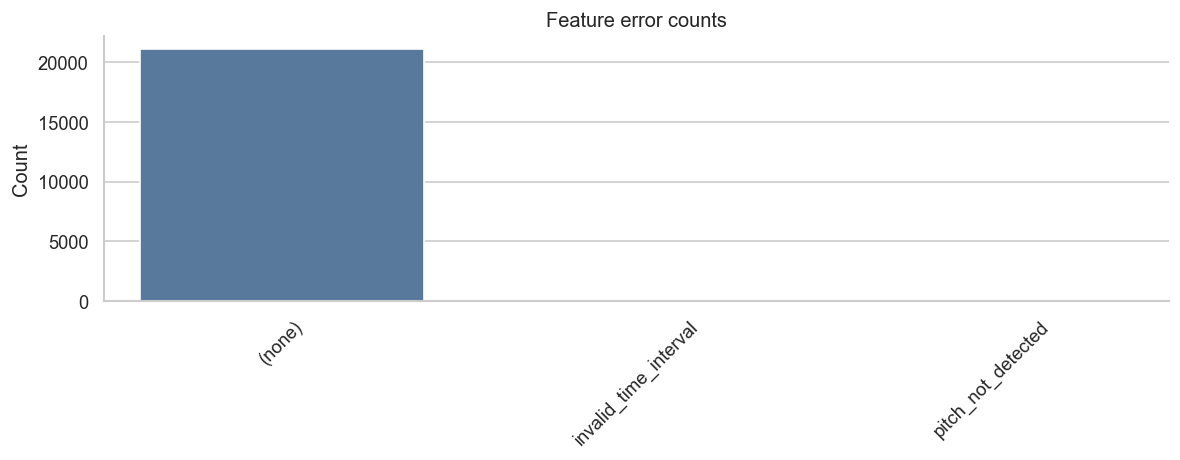

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\feature_error_counts.png


In [3]:
total_rows = len(qc_df)
successful_rows = int(qc_df['feature_status'].eq('success').sum())
failed_rows = int(qc_df['feature_status'].eq('failed').sum())

extraction_summary = pd.DataFrame([
    {'metric': 'total_rows', 'value': total_rows},
    {'metric': 'successful_rows', 'value': successful_rows},
    {'metric': 'failed_rows', 'value': failed_rows},
    {'metric': 'success_percentage', 'value': round((successful_rows / total_rows) * 100, 2)},
    {'metric': 'failed_percentage', 'value': round((failed_rows / total_rows) * 100, 2)},
])
status_counts = qc_df['feature_status'].fillna('missing').value_counts().rename_axis('feature_status').reset_index(name='n_rows')
error_summary = qc_df['feature_error'].replace('', '(none)').value_counts().rename_axis('feature_error').reset_index(name='n_rows')

save_table(extraction_summary, 'extraction_summary.csv')
save_table(error_summary, 'error_summary.csv')

print(extraction_summary)
print('\nfeature_status counts:')
print(status_counts)
print('\nfeature_error counts:')
print(error_summary.head(20))

plot_count(qc_df['feature_status'].fillna('missing'), 'Feature status counts', 'feature_status_counts.png')
plot_count(qc_df['feature_error'].replace('', '(none)'), 'Feature error counts', 'feature_error_counts.png', max_n=15)


## 4. Duration analysis

Check whether duration patterns help explain failures and whether duration distributions look sensible across vowels, registers, speakers, activities, statuses, and errors.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\duration_summary.csv
Duration summary overall:
   n_non_missing  n_missing  missing_pct        mean  median        std    min    p05    p25     p75     p95      max  \
0        21341.0        0.0          0.0  100.201206   77.85  92.787407  30.22  50.43  61.74  104.14  209.06  2693.65   

  summary_level group  
0       overall   all  

Duration summary by vowel:
  group  n_non_missing  n_missing  missing_pct       mean  median        std    min      p05      p25       p75  \
0     a         5164.0        0.0          0.0  94.127432  78.045  68.231996  33.48  50.9015  62.9375  100.6400   
1    ai         1886.0        0.0          0.0  97.538378  73.415  92.664872  34.17  50.1750  58.7750   96.8950   
2    an         1348.0        0.0          0.0  99.027010  82.000  70.998173  40.04  51.0645  64.4850  109.1000   
3    au          751.0        0.0          0.0  97.684514  76.590

   speakerid  n_non_missing  n_missing  missing_pct        mean   median         std    min     p05      p25  \
0       c009          613.0        0.0          0.0  114.603540   93.440   82.360732  37.46  53.216  70.3100   
1       c010          238.0        0.0          0.0  197.167311  104.465  258.509016  48.07  55.180  76.4125   
2       c012          910.0        0.0          0.0  136.090110  104.005  127.063395  41.32  59.530  79.0500   
3       c018         3713.0        0.0          0.0   91.649480   76.060   61.626558  37.63  49.636  59.7700   
4       c021         1155.0        0.0          0.0   90.941385   67.590   96.070872  30.22  43.930  55.2900   
5       c023          174.0        0.0          0.0  127.129195   95.215  101.881362  49.46  55.039  70.8400   
6       c027          630.0        0.0          0.0   85.166000   61.090   97.753804  40.35  45.859  51.8700   
7       c028          830.0        0.0          0.0   99.768205   86.240   59.932090  34.87  51.999  69.

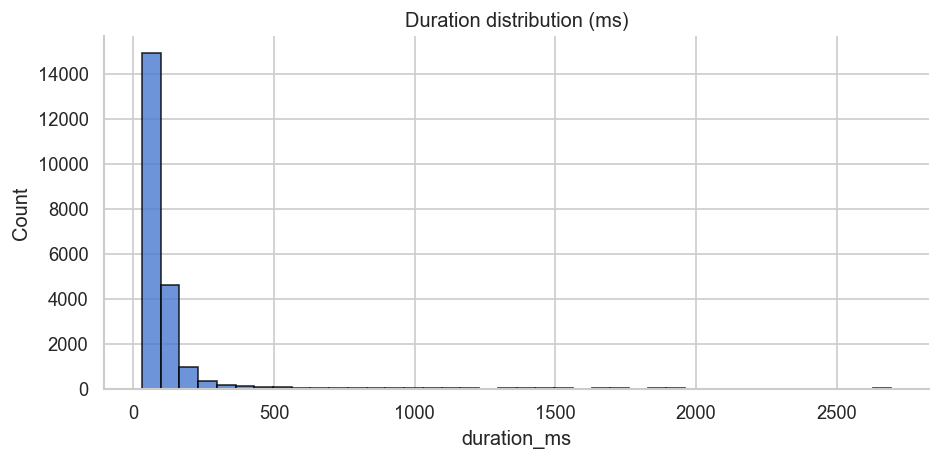

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_histogram.png


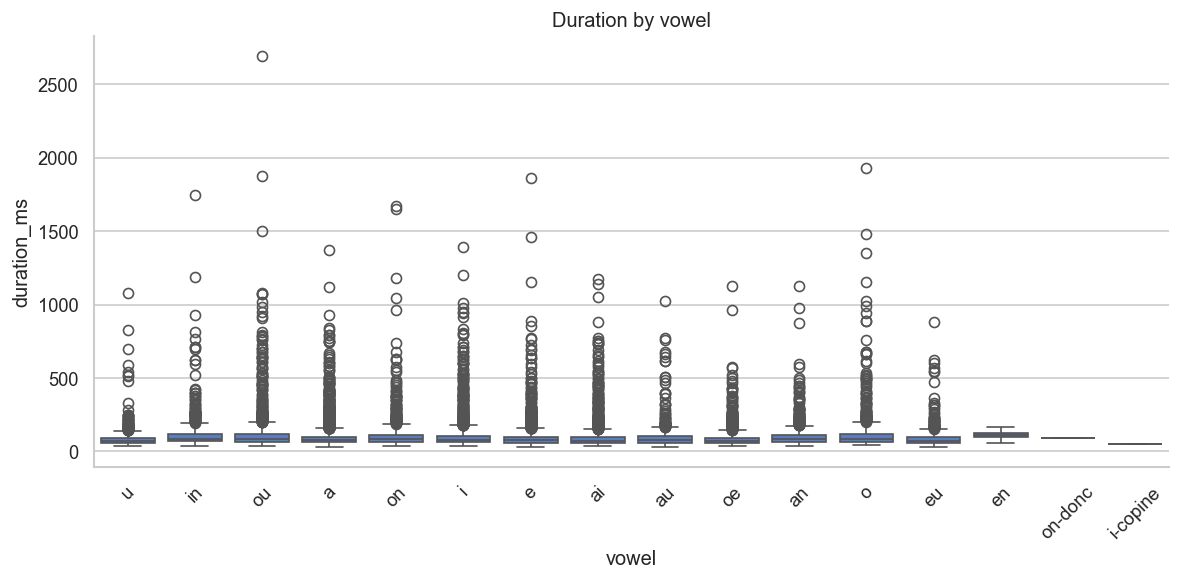

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_by_vowel.png


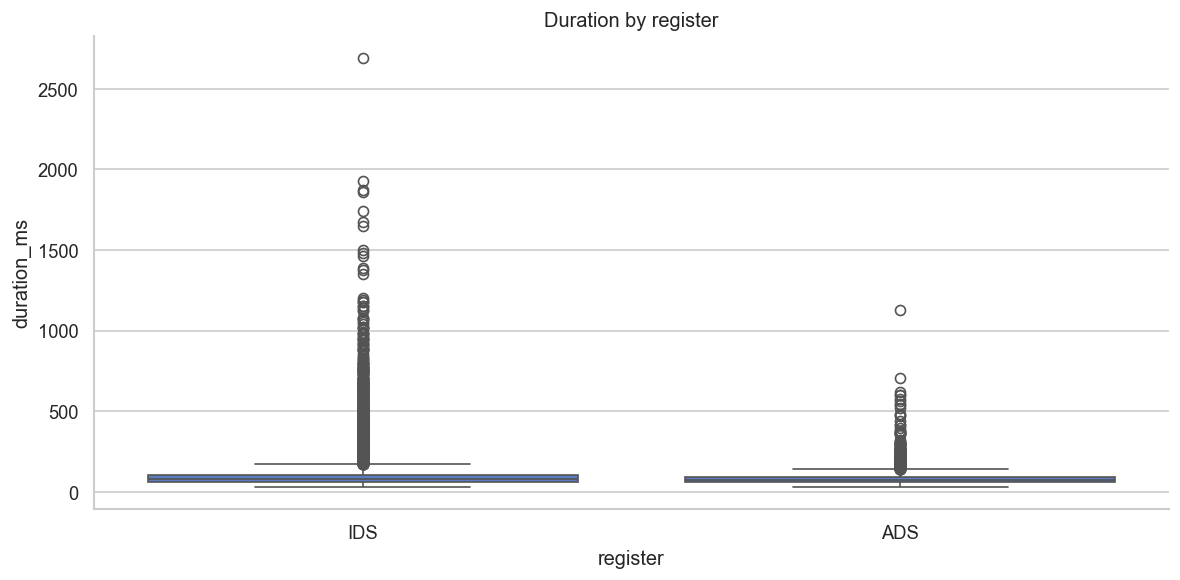

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_by_register.png


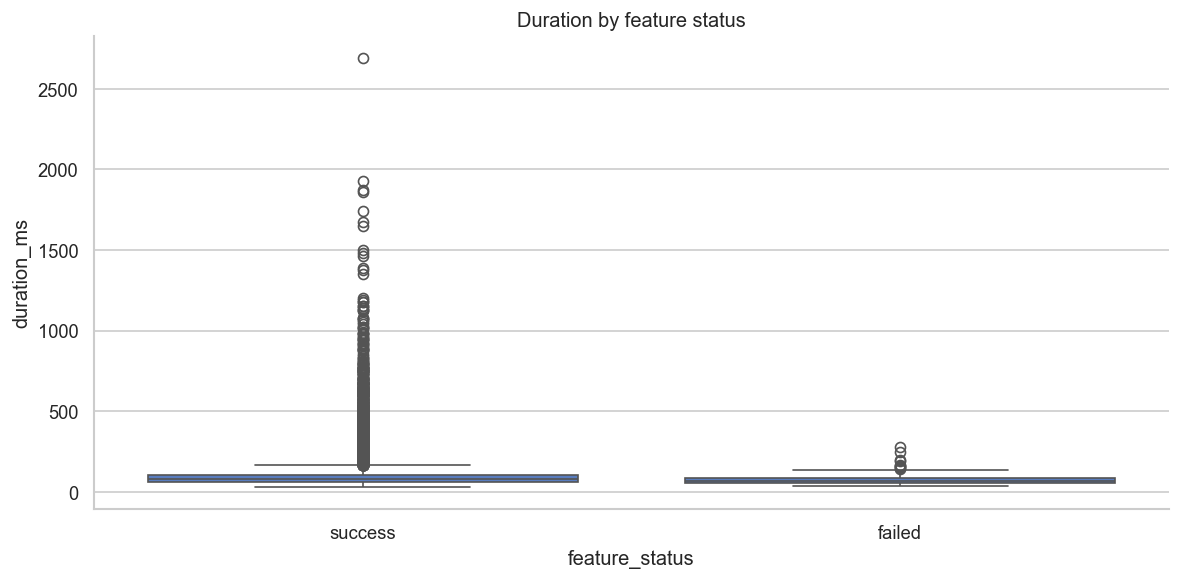

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_by_status.png


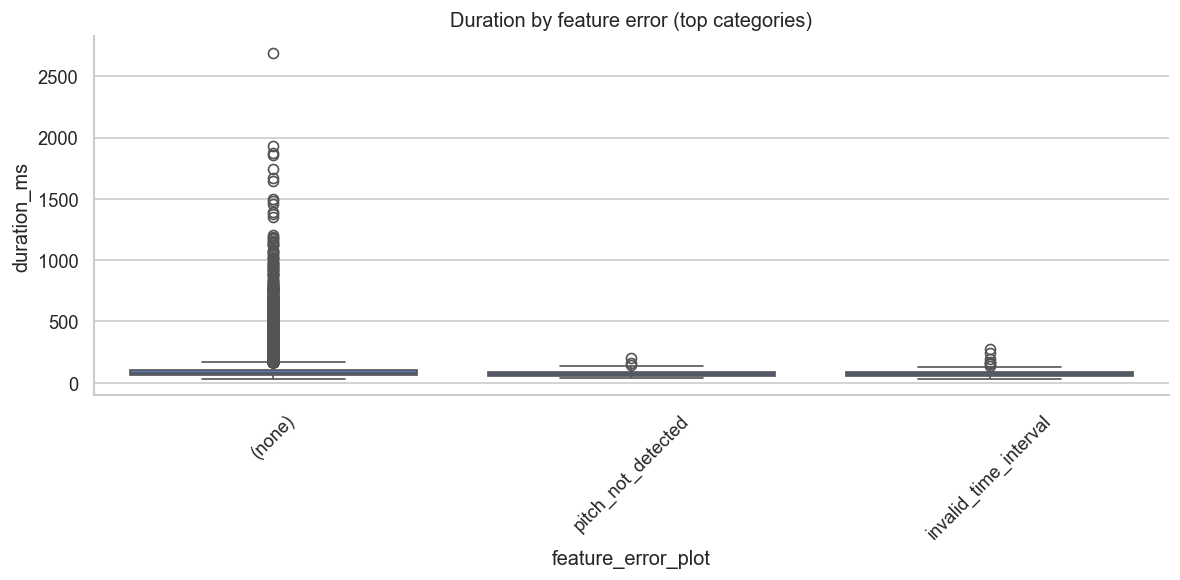

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_by_error.png


In [4]:
duration_overall = pd.DataFrame([numeric_summary(qc_df['duration_ms'])]).assign(summary_level='overall', group='all')
duration_by_vowel = grouped_numeric_summary(qc_df, 'vowel', 'duration_ms').rename(columns={'vowel': 'group'}).assign(summary_level='vowel')
duration_by_register = grouped_numeric_summary(qc_df, 'register', 'duration_ms').rename(columns={'register': 'group'}).assign(summary_level='register')
duration_by_status = grouped_numeric_summary(qc_df, 'feature_status', 'duration_ms').rename(columns={'feature_status': 'group'}).assign(summary_level='feature_status')
duration_summary = pd.concat([duration_overall, duration_by_vowel, duration_by_register, duration_by_status], ignore_index=True)
save_table(duration_summary, 'duration_summary.csv')

print('Duration summary overall:')
print(duration_overall)
print('\nDuration summary by vowel:')
print(duration_by_vowel.head())
print('\nDuration summary by register:')
print(duration_by_register)
print('\nDuration summary by feature_status:')
print(duration_by_status)
print('\nDuration summary by speakerid (top 15 by token count):')
print(grouped_numeric_summary(qc_df, 'speakerid', 'duration_ms').head(15))
print('\nDuration summary by activity:')
print(grouped_numeric_summary(qc_df, 'activity', 'duration_ms'))

plot_hist(qc_df, 'duration_ms', 'Duration distribution (ms)', 'duration_histogram.png')
plot_box(qc_df, 'vowel', 'duration_ms', 'Duration by vowel', 'duration_by_vowel.png', rotate=45)
plot_box(qc_df, 'register', 'duration_ms', 'Duration by register', 'duration_by_register.png', order=REGISTER_ORDER, rotate=0)
plot_box(qc_df, 'feature_status', 'duration_ms', 'Duration by feature status', 'duration_by_status.png', rotate=0)
error_levels = top_categories(qc_df['feature_error'].replace('', '(none)'), max_n=12)
duration_error_df = qc_df.assign(feature_error_plot=qc_df['feature_error'].replace('', '(none)'))
duration_error_df = duration_error_df[duration_error_df['feature_error_plot'].isin(error_levels)]
plot_box(duration_error_df, 'feature_error_plot', 'duration_ms', 'Duration by feature error (top categories)', 'duration_by_error.png', rotate=45)


## 5. Pitch feature analysis

Inspect pitch summaries, missingness, differences by vowel and register, and duration relationships. This section also flags obviously suspicious pitch values.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\pitch_summary.csv
       feature  n_non_missing  n_missing  missing_pct        mean      median         std        min         p05  \
0   mean_pitch        21106.0      235.0     1.101167  276.582786  257.798703   93.854172  99.871477  152.537817   
1    min_pitch        21106.0      235.0     1.101167  264.699194  247.974145   89.374052  99.693622  143.738385   
2    max_pitch        21106.0      235.0     1.101167  288.342347  266.256978  101.064534  99.871477  157.466502   
3  pitch_range        21106.0      235.0     1.101167   23.643153   10.823566   40.988144   0.000000    1.444924   

          p25         p75         p95         max  
0  209.857535  328.085093  464.710645  596.923961  
1  202.161056  311.587713  443.307580  593.988151  
2  216.714893  342.679283  494.345364  599.999314  
3    4.909659   23.861731   90.869352  480.490551  
mean_pitch: missing 1.10%
min_pi

   speakerid  n_non_missing  n_missing  missing_pct        mean      median         std         min         p05  \
0       c009          606.0        0.0          0.0  275.683732  262.559123   86.360594  102.634301  160.244241   
1       c010          238.0        0.0          0.0  282.375040  261.840420   93.592506  109.500758  167.067964   
2       c012          900.0        0.0          0.0  272.049323  263.472153   86.197816  100.703054  150.913251   
3       c018         3704.0        0.0          0.0  327.081369  313.093053  105.000905  101.363301  177.435662   
4       c021         1011.0        0.0          0.0  255.232697  229.242219   98.660826  102.739058  145.421571   
5       c023          174.0        0.0          0.0  283.334840  269.024126   79.757920  113.028439  182.344743   
6       c027          629.0        0.0          0.0  251.825179  244.754169   71.956660  103.388458  140.627008   
7       c028          825.0        0.0          0.0  311.518865  302.622698   96

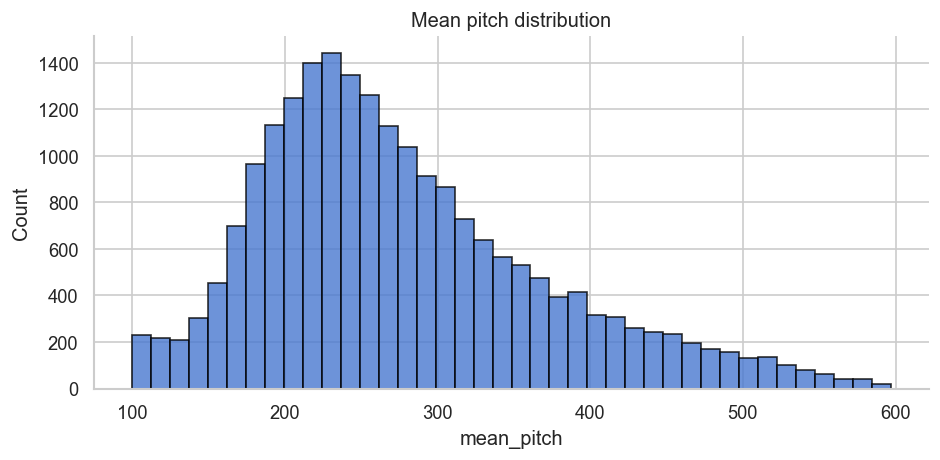

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_pitch_histogram.png


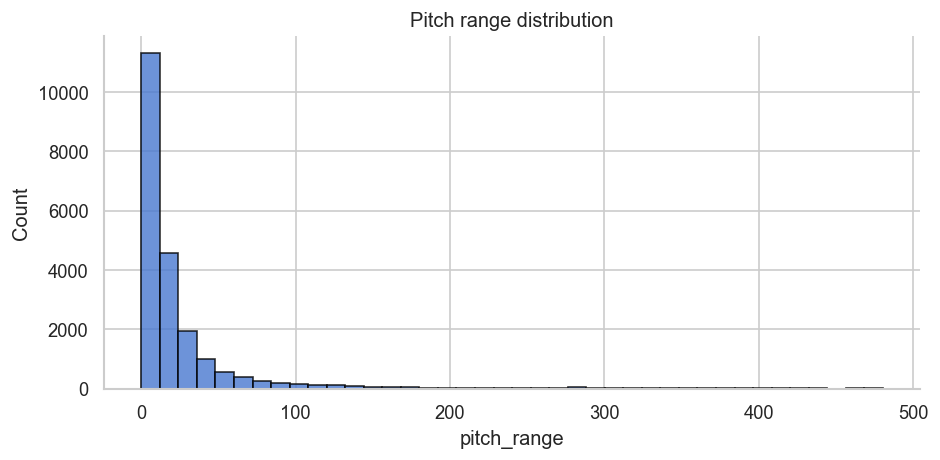

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\pitch_range_histogram.png


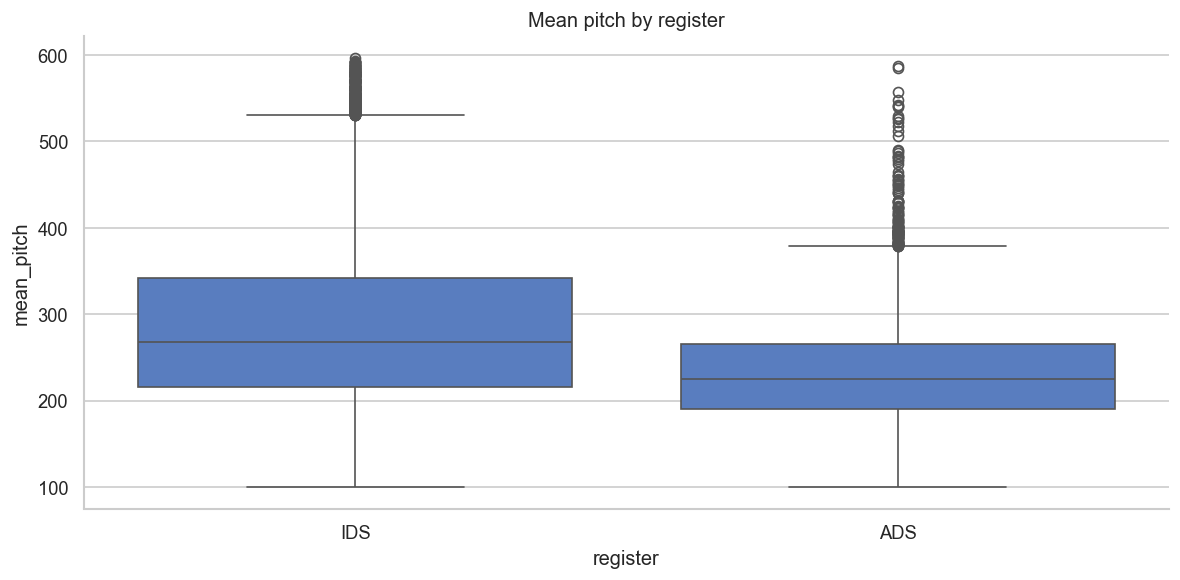

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_pitch_by_register.png


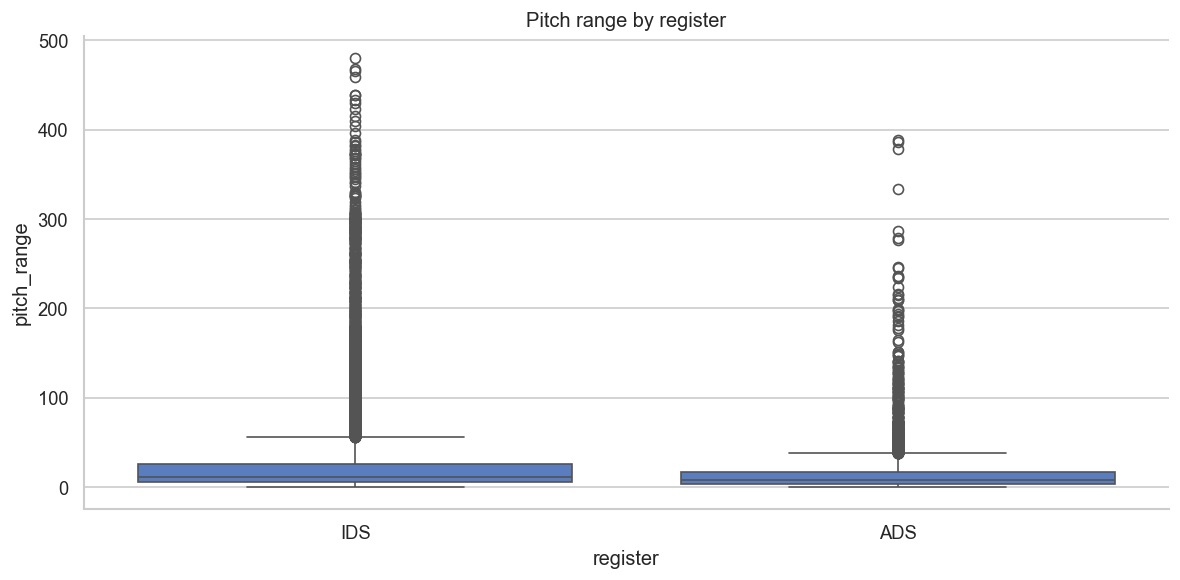

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\pitch_range_by_register.png


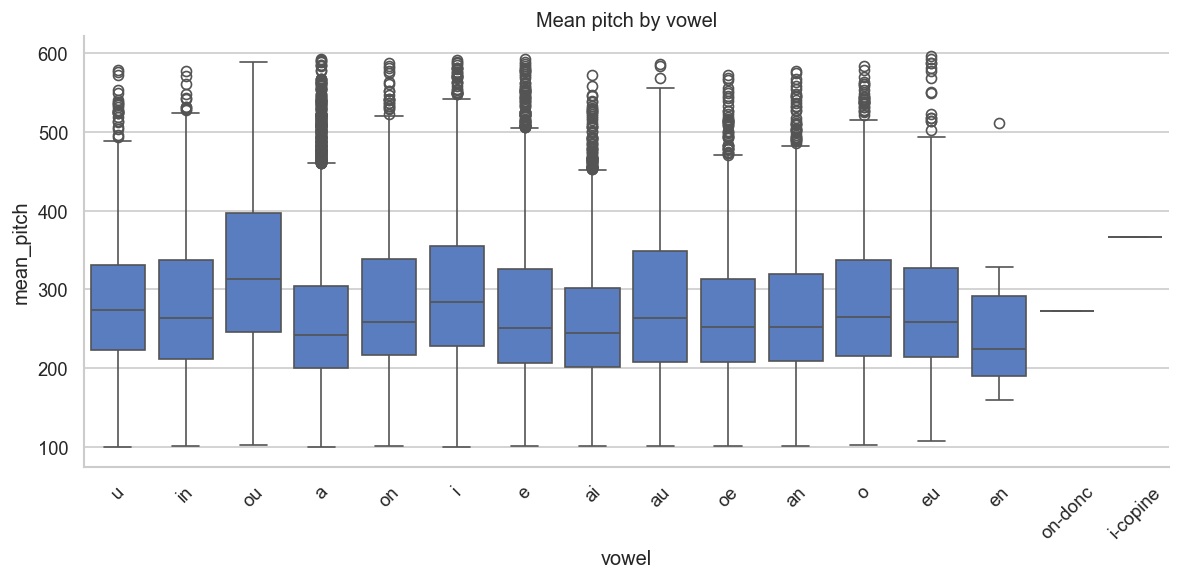

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_pitch_by_vowel.png


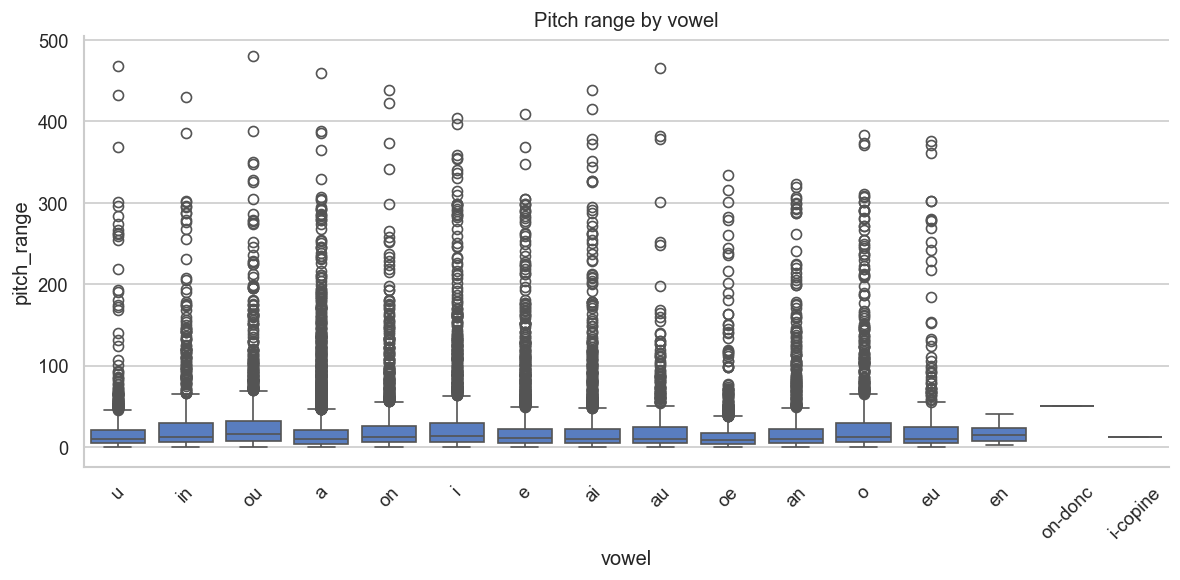

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\pitch_range_by_vowel.png


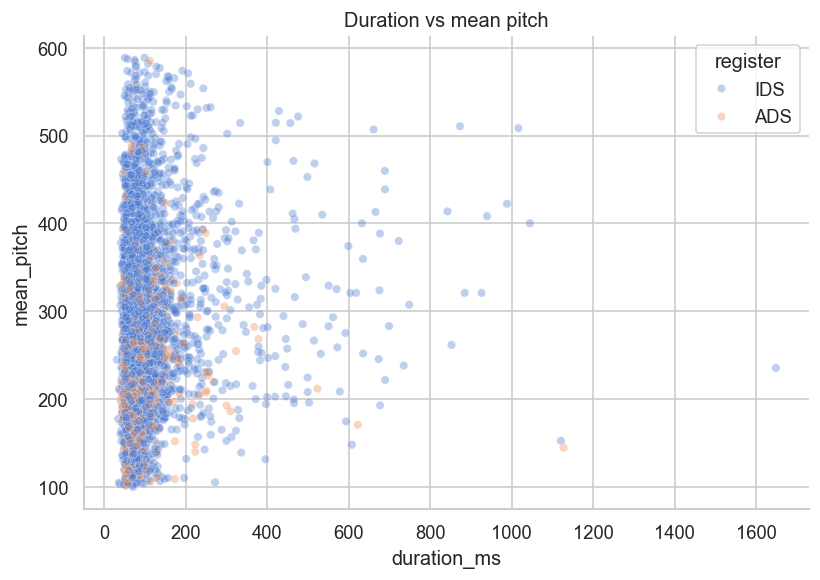

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_vs_mean_pitch.png


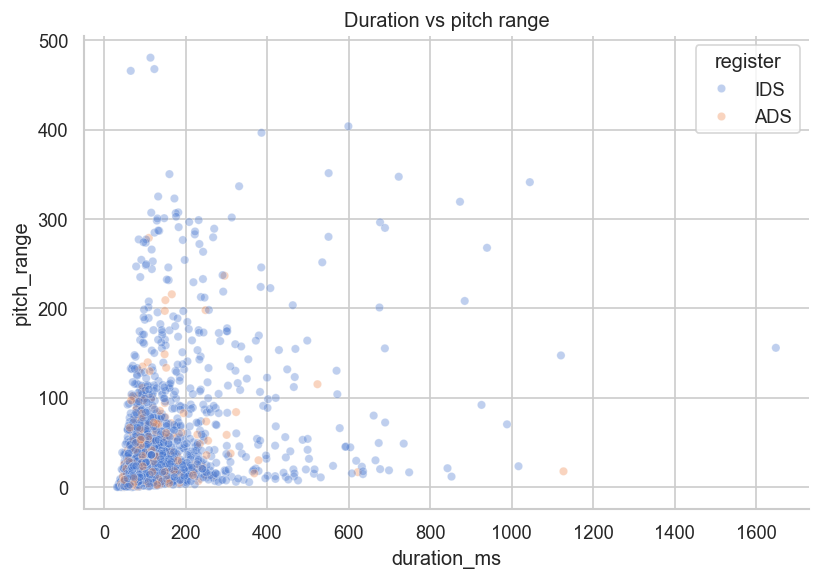

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_vs_pitch_range.png
Rows with mean_pitch > 600 Hz: 0
Rows with pitch_range > 500 Hz: 0


In [5]:
pitch_summary = pd.DataFrame([numeric_summary(qc_df[col]) for col in PITCH_COLS], index=PITCH_COLS).reset_index().rename(columns={'index': 'feature'})
save_table(pitch_summary, 'pitch_summary.csv')
print(pitch_summary)

for col in PITCH_COLS:
    missing_pct = qc_df[col].isna().mean() * 100
    print(f'{col}: missing {missing_pct:.2f}%')

print('\nPitch by vowel (mean_pitch):')
print(grouped_numeric_summary(success_df, 'vowel', 'mean_pitch').head())
print('\nPitch by register (mean_pitch):')
print(grouped_numeric_summary(success_df, 'register', 'mean_pitch'))
print('\nPitch by speakerid (mean_pitch, top 15 speakers):')
print(grouped_numeric_summary(success_df, 'speakerid', 'mean_pitch').head(15))
print('\nPitch by activity (mean_pitch):')
print(grouped_numeric_summary(success_df, 'activity', 'mean_pitch'))
print('\nPitch range by vowel:')
print(grouped_numeric_summary(success_df, 'vowel', 'pitch_range').head())
print('\nPitch range by register:')
print(grouped_numeric_summary(success_df, 'register', 'pitch_range'))

plot_hist(success_df, 'mean_pitch', 'Mean pitch distribution', 'mean_pitch_histogram.png')
plot_hist(success_df, 'pitch_range', 'Pitch range distribution', 'pitch_range_histogram.png')
plot_box(success_df, 'register', 'mean_pitch', 'Mean pitch by register', 'mean_pitch_by_register.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'pitch_range', 'Pitch range by register', 'pitch_range_by_register.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'vowel', 'mean_pitch', 'Mean pitch by vowel', 'mean_pitch_by_vowel.png', rotate=45)
plot_box(success_df, 'vowel', 'pitch_range', 'Pitch range by vowel', 'pitch_range_by_vowel.png', rotate=45)
plot_scatter(success_df, 'duration_ms', 'mean_pitch', 'Duration vs mean pitch', 'duration_vs_mean_pitch.png', hue='register')
plot_scatter(success_df, 'duration_ms', 'pitch_range', 'Duration vs pitch range', 'duration_vs_pitch_range.png', hue='register')

mean_pitch_gt_600 = int(success_df['mean_pitch'].gt(600).fillna(False).sum())
pitch_range_gt_500 = int(success_df['pitch_range'].gt(500).fillna(False).sum())
print(f'Rows with mean_pitch > 600 Hz: {mean_pitch_gt_600}')
print(f'Rows with pitch_range > 500 Hz: {pitch_range_gt_500}')


## 6. Formant feature analysis

Inspect formant distributions, missingness, and grouped summaries by vowel, register, speaker, and activity.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\formant_summary.csv
      feature  n_non_missing  n_missing  missing_pct         mean       median         std          min          p05  \
0     mean_F1        21106.0      235.0     1.101167   554.666597   531.320788  163.687769   158.950489   326.136073   
1     mean_F2        21106.0      235.0     1.101167  1794.121046  1802.355973  450.264590   516.112503  1034.586232   
2     mean_F3        21106.0      235.0     1.101167  2920.261260  2941.980006  421.196301  1220.898786  2178.433782   
3     mean_F4        21106.0      235.0     1.101167  4028.100112  4060.352064  465.328254  2593.361117  3207.776856   
4  central_F1        21106.0      235.0     1.101167   556.613319   530.732837  172.241653   137.152397   320.292103   
5  central_F2        21106.0      235.0     1.101167  1796.959152  1804.681618  468.277803   437.837094  1001.536575   
6  central_F3        21106.0   

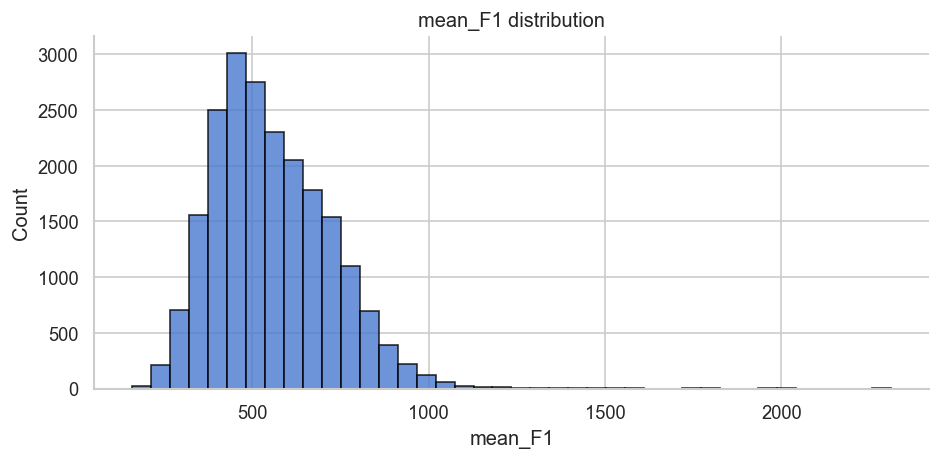

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F1_histogram.png


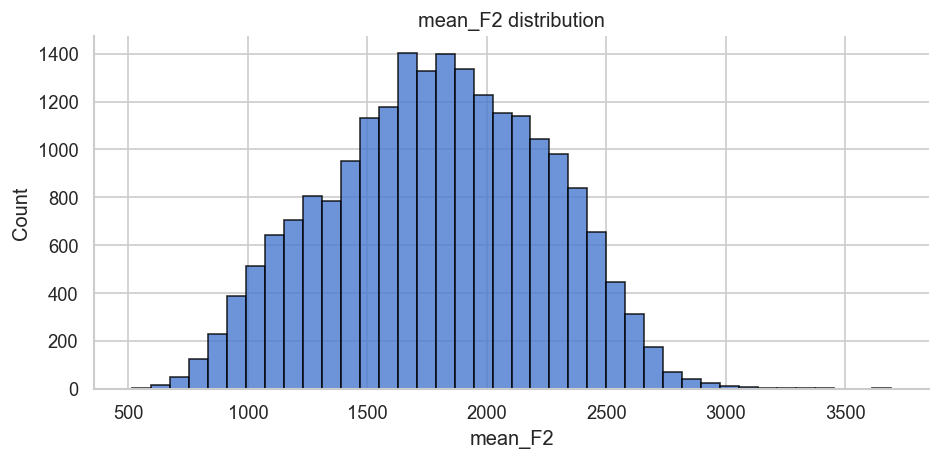

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F2_histogram.png


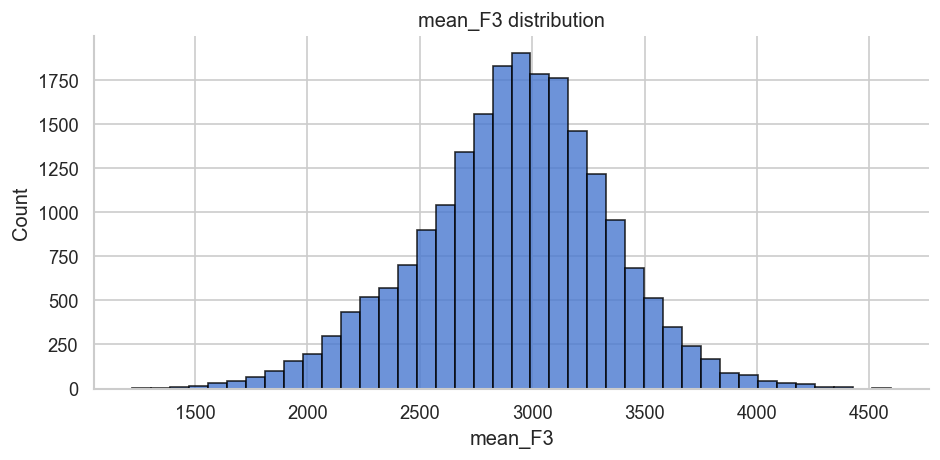

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F3_histogram.png


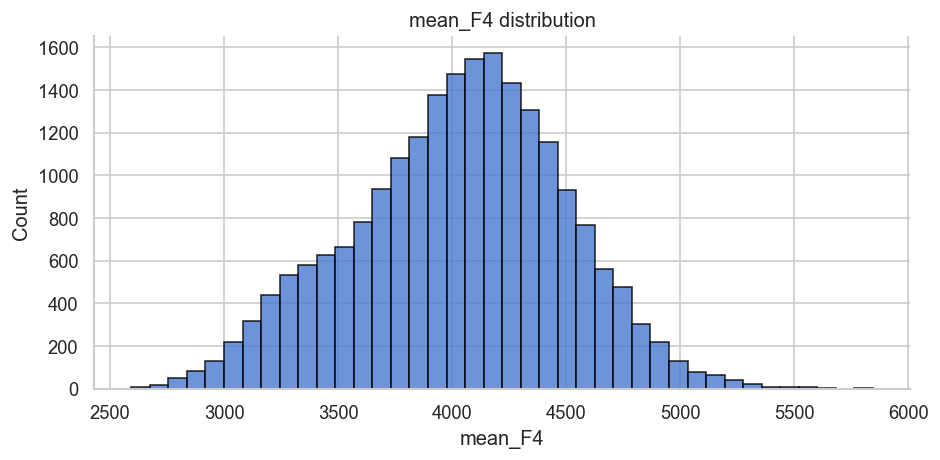

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F4_histogram.png


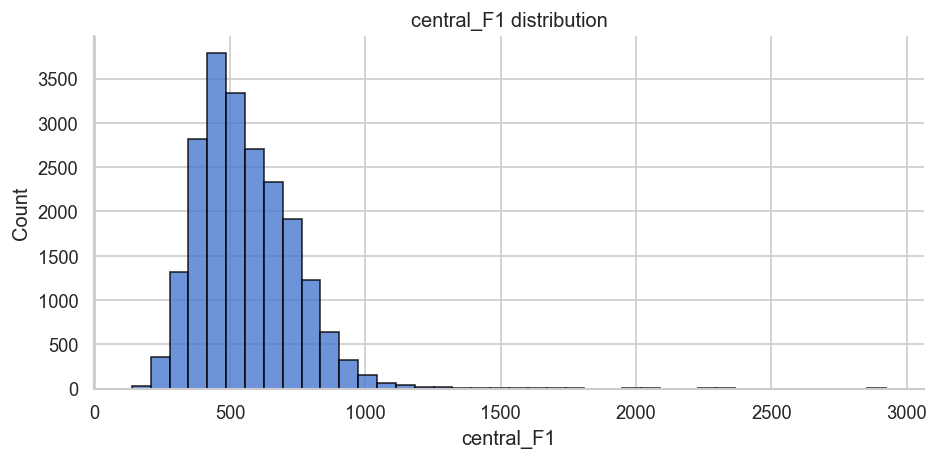

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\central_F1_histogram.png


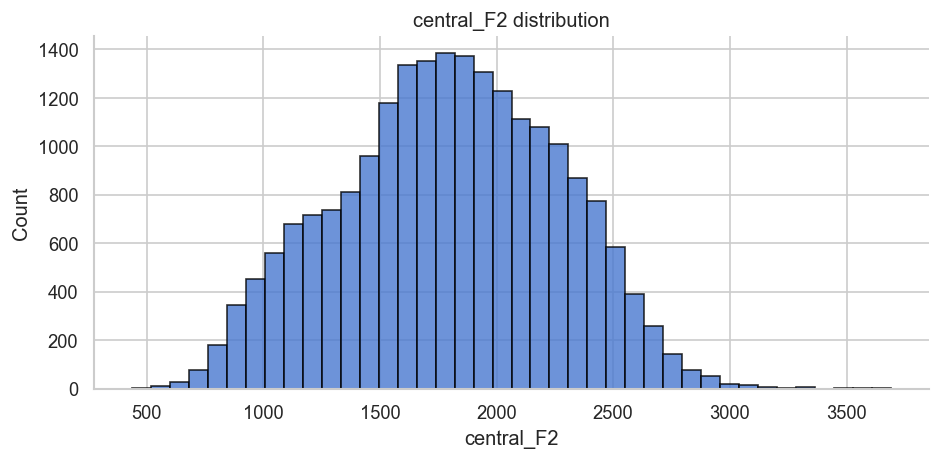

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\central_F2_histogram.png


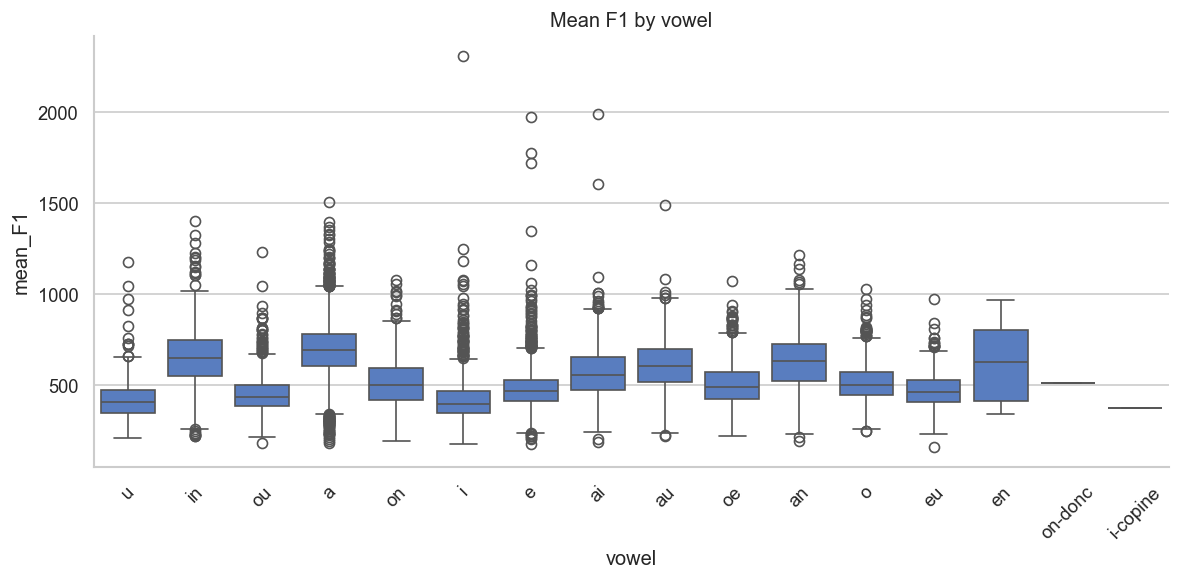

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F1_by_vowel.png


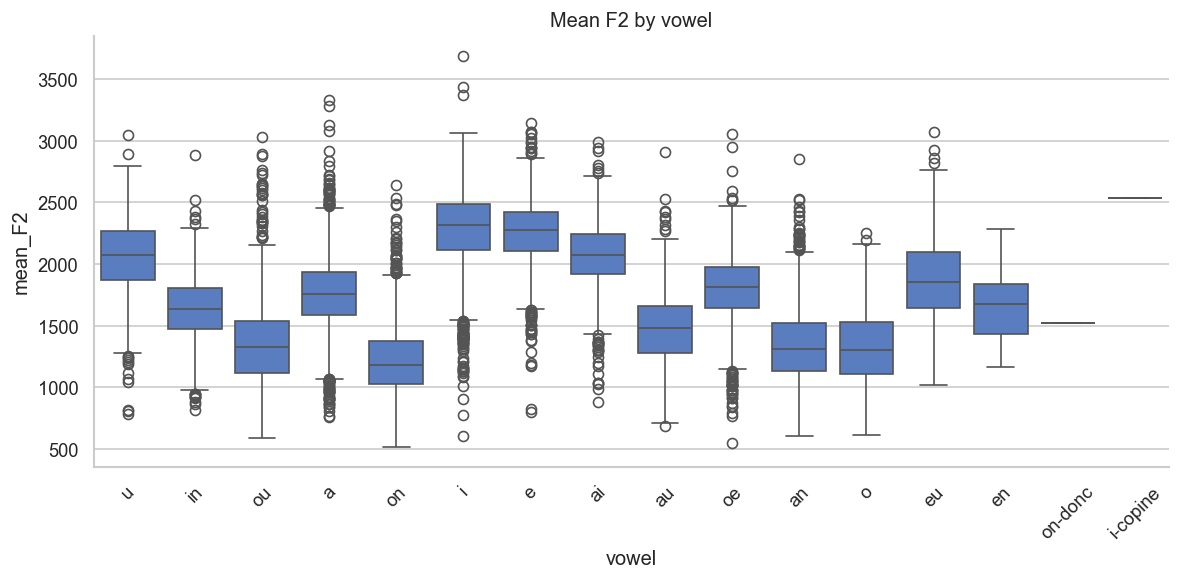

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F2_by_vowel.png


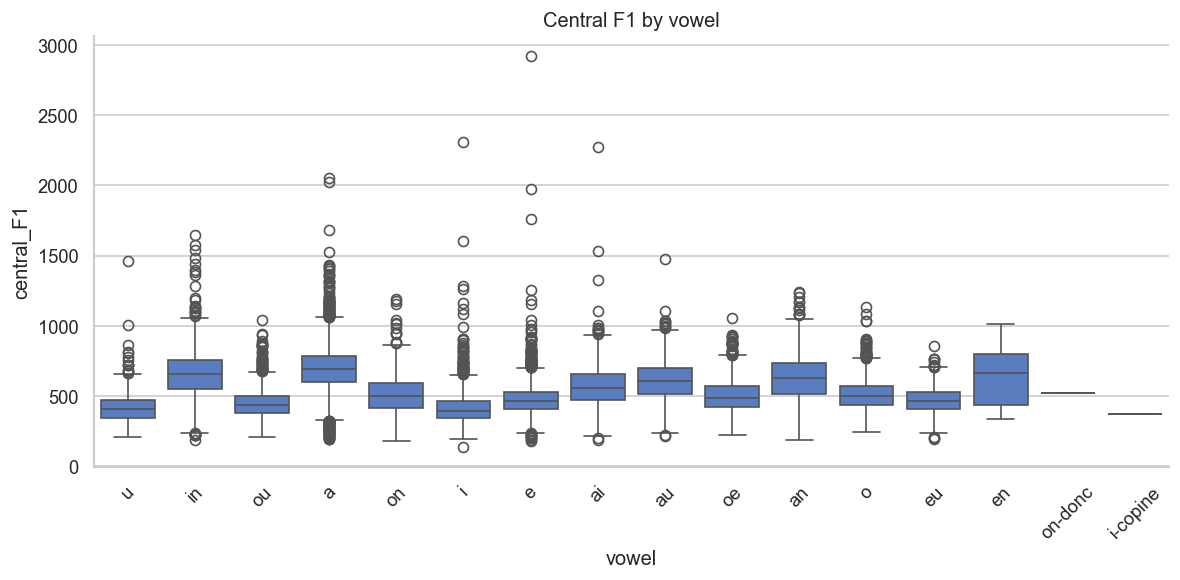

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\central_F1_by_vowel.png


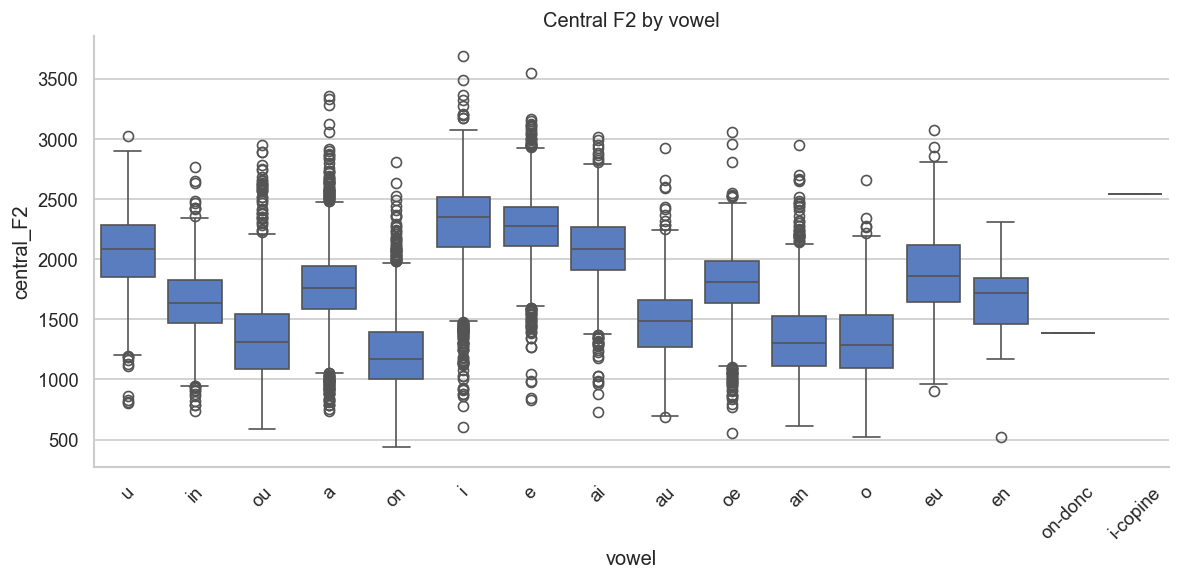

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\central_F2_by_vowel.png


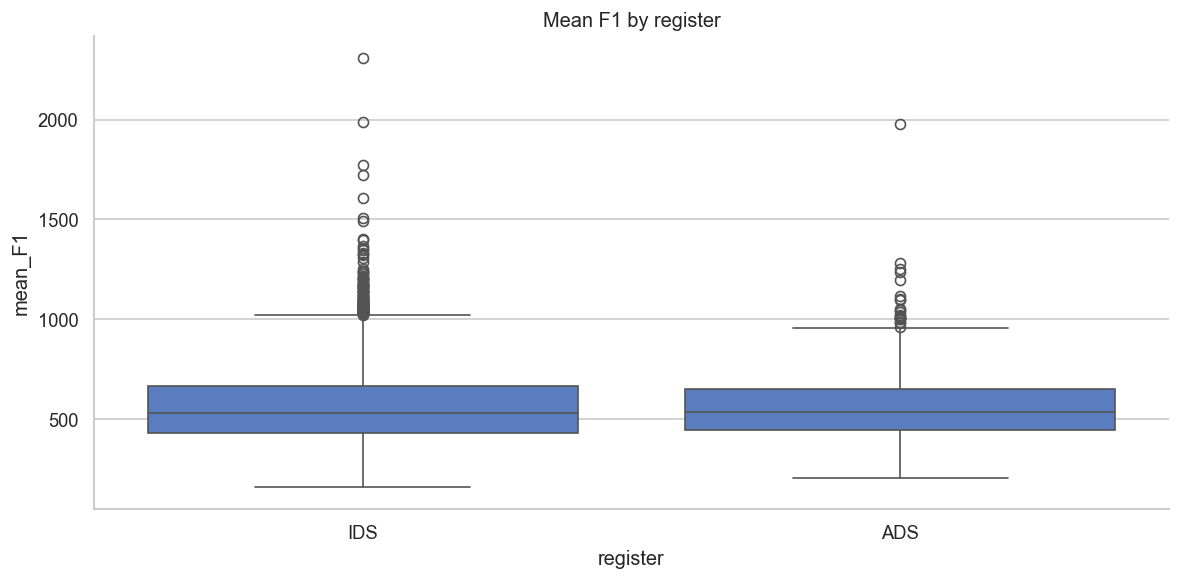

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F1_by_register.png


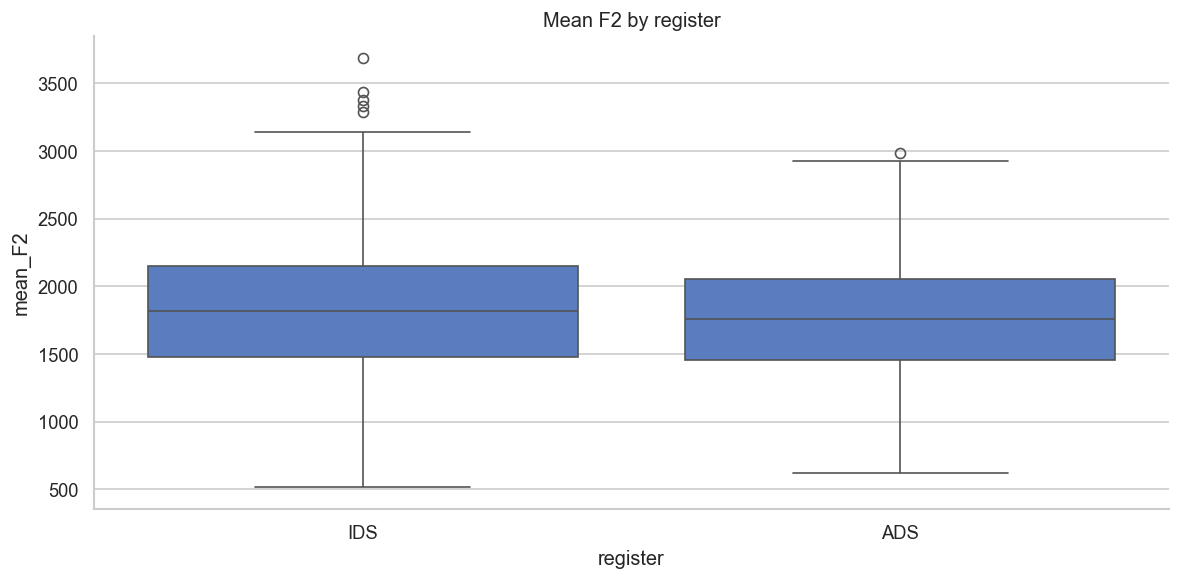

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_F2_by_register.png

Formants by vowel (mean_F1):
  vowel  n_non_missing  n_missing  missing_pct        mean      median         std         min         p05  \
0     a         5067.0        0.0          0.0  693.699366  690.732517  144.420082  183.351051  470.780709   
1    ai         1870.0        0.0          0.0  567.726175  557.579538  135.248922  184.038663  371.511357   
2    an         1338.0        0.0          0.0  621.986561  629.305293  151.166056  192.423238  364.527937   
3    au          747.0        0.0          0.0  610.688561  604.801728  141.303259  218.283213  398.349379   
4     e         2650.0        0.0          0.0  478.598354  466.432553  112.044229  173.176917  338.248921   

          p25         p75         p95          max  
0  604.296251  780.271252  931.457390  1505.238397  
1  474.377098  651.465059  788.375609  1988.274437  
2  521.20997

In [6]:
formant_summary = pd.DataFrame([numeric_summary(qc_df[col]) for col in FORMANT_COLS], index=FORMANT_COLS).reset_index().rename(columns={'index': 'feature'})
save_table(formant_summary, 'formant_summary.csv')
print(formant_summary)

for col in ['mean_F1', 'mean_F2', 'mean_F3', 'mean_F4', 'central_F1', 'central_F2']:
    plot_hist(success_df, col, f'{col} distribution', f'{col}_histogram.png')

plot_box(success_df, 'vowel', 'mean_F1', 'Mean F1 by vowel', 'mean_F1_by_vowel.png', rotate=45)
plot_box(success_df, 'vowel', 'mean_F2', 'Mean F2 by vowel', 'mean_F2_by_vowel.png', rotate=45)
plot_box(success_df, 'vowel', 'central_F1', 'Central F1 by vowel', 'central_F1_by_vowel.png', rotate=45)
plot_box(success_df, 'vowel', 'central_F2', 'Central F2 by vowel', 'central_F2_by_vowel.png', rotate=45)
plot_box(success_df, 'register', 'mean_F1', 'Mean F1 by register', 'mean_F1_by_register.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'mean_F2', 'Mean F2 by register', 'mean_F2_by_register.png', order=REGISTER_ORDER, rotate=0)

print('\nFormants by vowel (mean_F1):')
print(grouped_numeric_summary(success_df, 'vowel', 'mean_F1').head())
print('\nFormants by register (mean_F1):')
print(grouped_numeric_summary(success_df, 'register', 'mean_F1'))
print('\nFormants by speakerid (mean_F1, top 15):')
print(grouped_numeric_summary(success_df, 'speakerid', 'mean_F1').head(15))
print('\nFormants by activity (mean_F1):')
print(grouped_numeric_summary(success_df, 'activity', 'mean_F1'))


## 7. Vowel-space plots

Create raw mean and central vowel-space plots, vowel centroids, and a split-by-register view for IDS versus ADS.

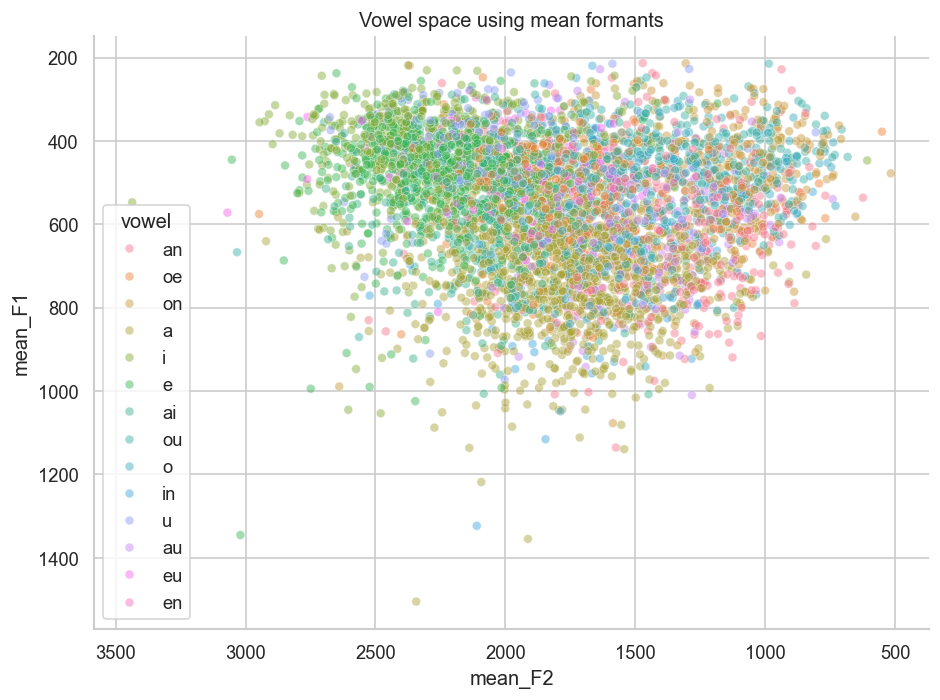

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\vowel_space_mean.png


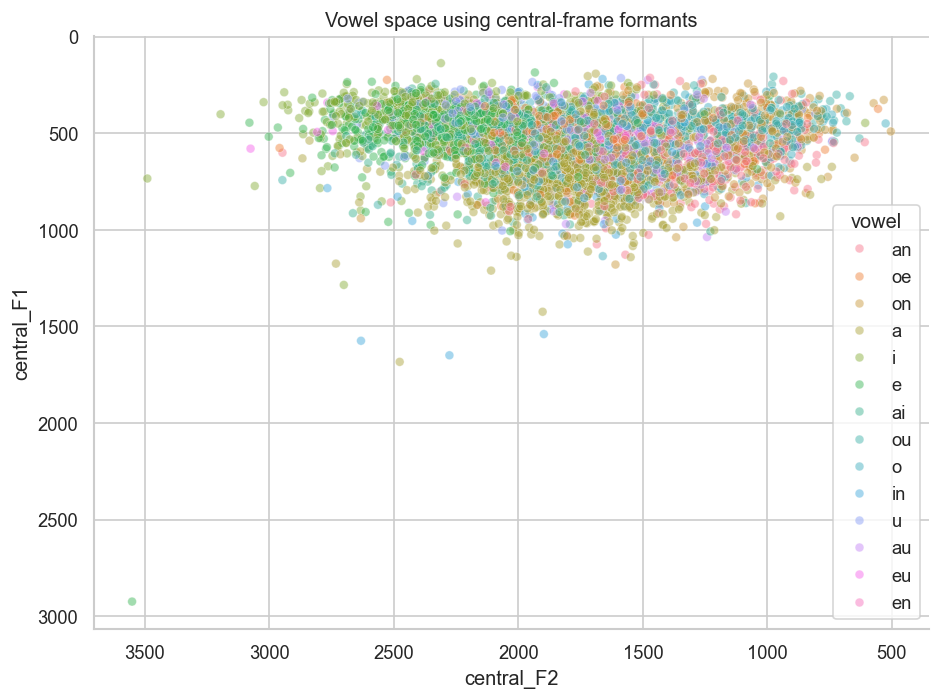

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\vowel_space_central.png


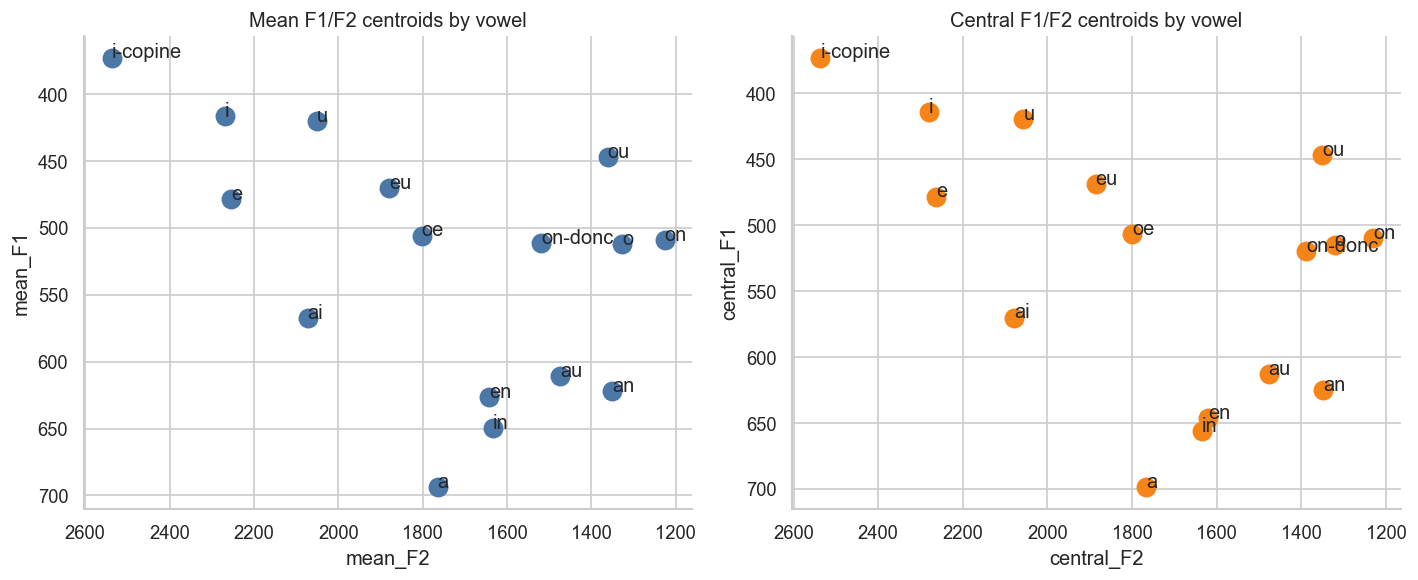

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\vowel_centroids.png


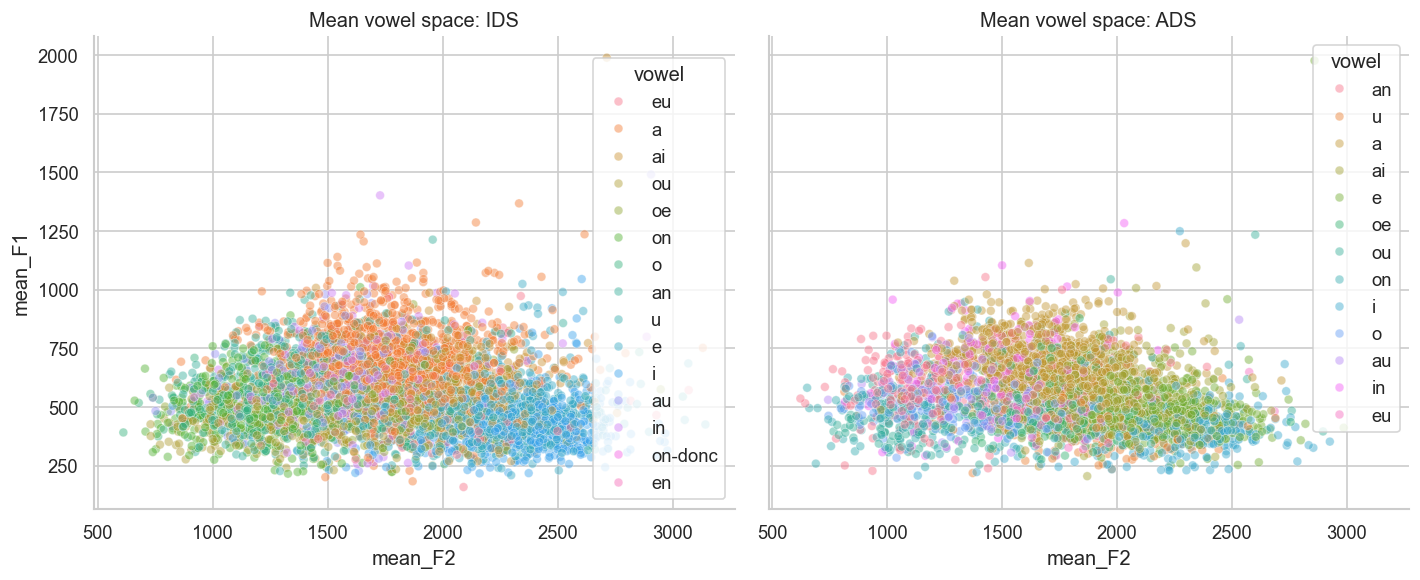

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\vowel_space_by_register.png


In [7]:
plot_vowel_space(success_df, 'mean_F1', 'mean_F2', 'Vowel space using mean formants', 'vowel_space_mean.png')
plot_vowel_space(success_df, 'central_F1', 'central_F2', 'Vowel space using central-frame formants', 'vowel_space_central.png')

mean_centroids = success_df.groupby('vowel', dropna=False)[['mean_F1', 'mean_F2']].mean().reset_index()
central_centroids = success_df.groupby('vowel', dropna=False)[['central_F1', 'central_F2']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(mean_centroids['mean_F2'], mean_centroids['mean_F1'], s=120, color='#4C78A8')
for _, row in mean_centroids.iterrows():
    axes[0].text(row['mean_F2'], row['mean_F1'], str(row['vowel']))
axes[0].invert_xaxis()
axes[0].invert_yaxis()
axes[0].set_title('Mean F1/F2 centroids by vowel')
axes[0].set_xlabel('mean_F2')
axes[0].set_ylabel('mean_F1')

axes[1].scatter(central_centroids['central_F2'], central_centroids['central_F1'], s=120, color='#F58518')
for _, row in central_centroids.iterrows():
    axes[1].text(row['central_F2'], row['central_F1'], str(row['vowel']))
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_title('Central F1/F2 centroids by vowel')
axes[1].set_xlabel('central_F2')
axes[1].set_ylabel('central_F1')
finish_plot(fig, 'vowel_centroids.png')

register_space_df = success_df[success_df['register'].isin(REGISTER_ORDER)].dropna(subset=['mean_F1', 'mean_F2'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, register in zip(axes, REGISTER_ORDER):
    subset = sample_for_scatter(register_space_df[register_space_df['register'] == register][['mean_F1', 'mean_F2', 'vowel']].dropna())
    sns.scatterplot(data=subset, x='mean_F2', y='mean_F1', hue='vowel', ax=ax, alpha=0.45, s=28)
    ax.set_title(f'Mean vowel space: {register}')
    ax.invert_xaxis()
    ax.invert_yaxis()
finish_plot(fig, 'vowel_space_by_register.png')


## 8. Mean vs central formant comparison

Compare mean versus central formants directly, save difference summaries, and inspect whether differences vary by vowel or register.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\central_vs_mean_formants.csv
   feature  n_non_missing  n_missing  missing_pct      mean  median         std          min         p05        p25  \
0  F1_diff        21106.0        0.0     0.000000  1.946722     0.0   45.528215 -1250.850242  -38.961977  -2.694417   
1  F2_diff        21106.0        0.0     0.000000  2.838107     0.0  117.807647 -1248.364596 -139.945917 -17.687093   
2  F3_diff        21106.0        0.0     0.000000  2.590808     0.0  157.292730 -1367.064686 -214.519505 -27.471767   
3  F4_diff        21058.0       48.0     0.227423  1.754329     0.0  169.657544 -1686.176227 -252.167715 -36.097961   

         p75         p95          max  
0   6.196604   48.724972  1578.082054  
1  18.545689  151.010595  1677.305439  
2  28.080619  236.340474  1303.420696  
3  32.976139  275.763926  1362.746949  


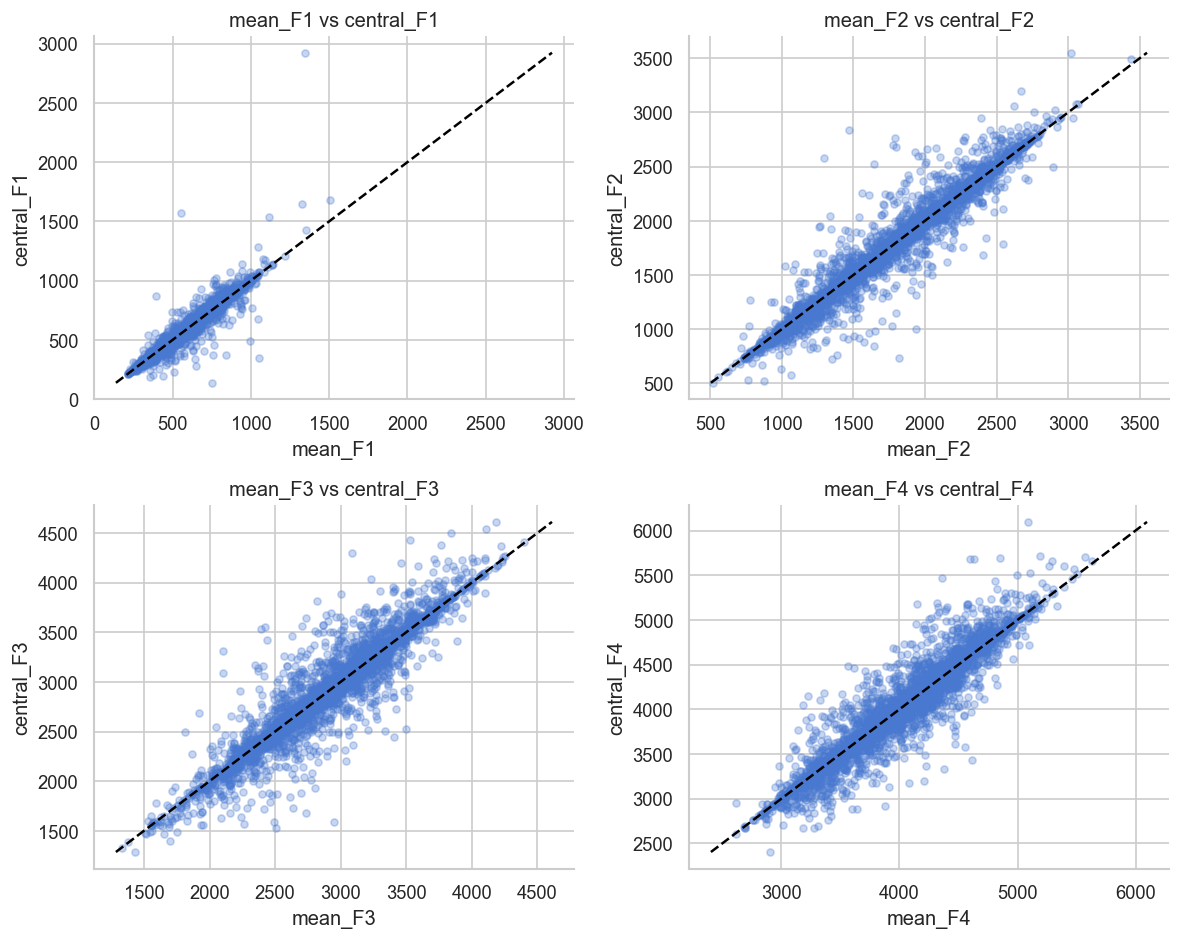

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\mean_vs_central_scatter.png


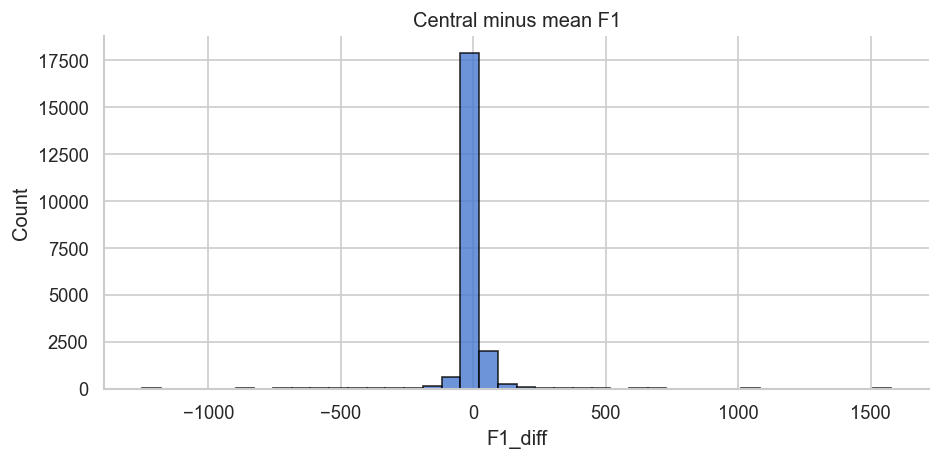

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\F1_diff_histogram.png


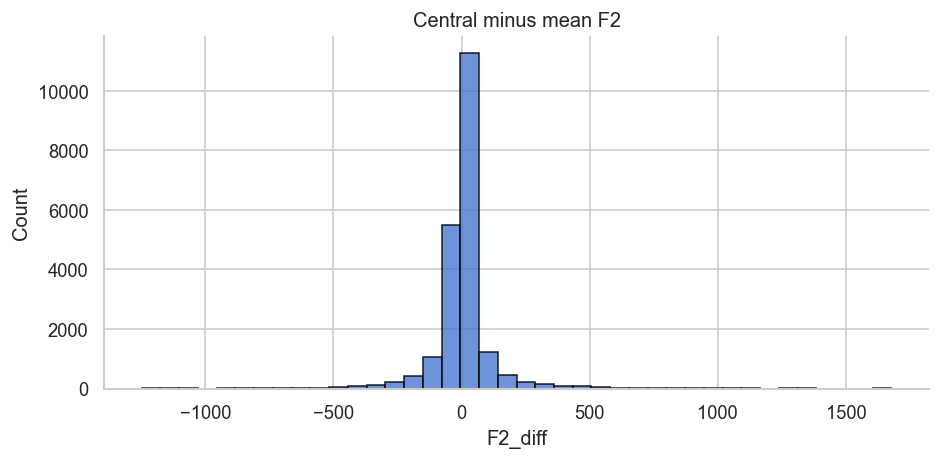

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\F2_diff_histogram.png


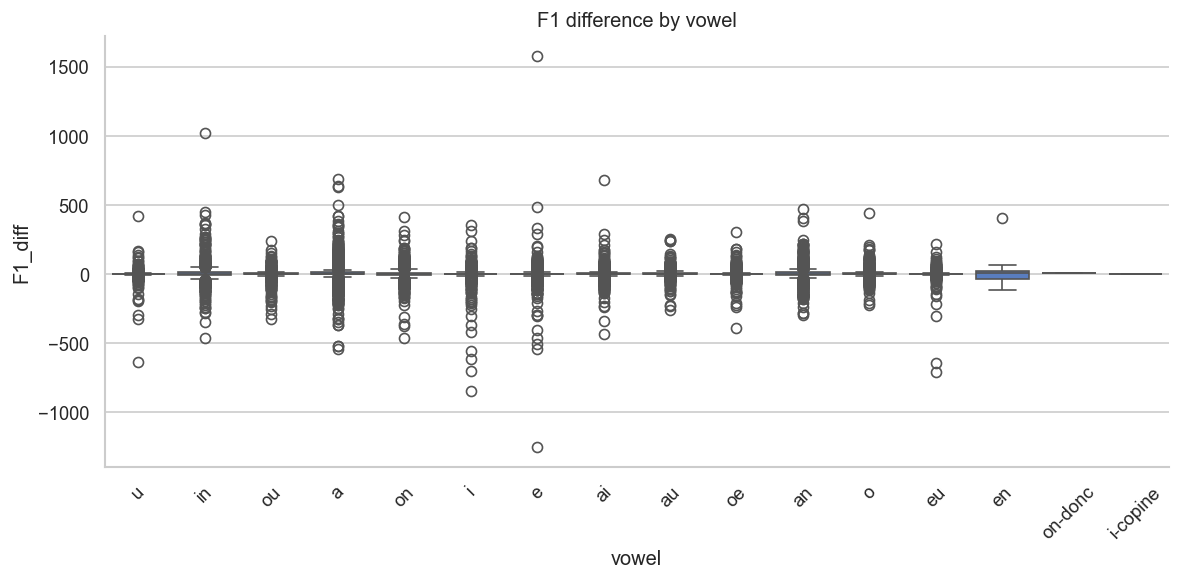

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\F1_diff_by_vowel.png


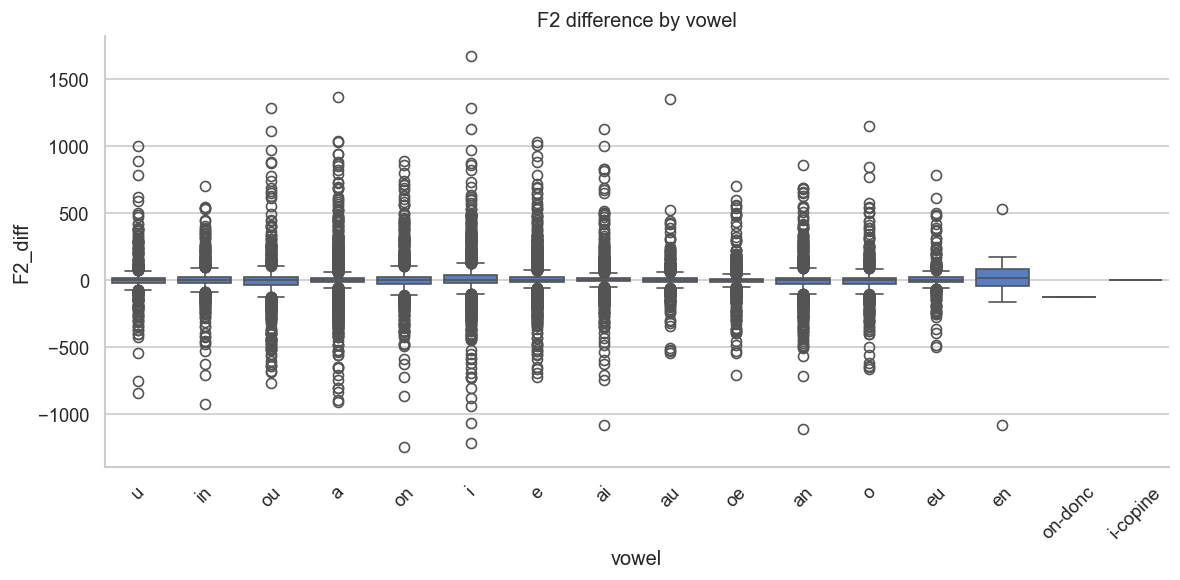

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\F2_diff_by_vowel.png

Difference by register:
         F1_diff        F2_diff        F3_diff        F4_diff       
            mean median    mean median    mean median    mean median
register                                                            
IDS         1.93    0.0    3.30    0.0    2.93    0.0    1.50    0.0
ADS         2.05    0.0    0.61    0.0    0.99    0.0    2.97    0.0


In [8]:
comparison_df = success_df.copy()
comparison_df['F1_diff'] = comparison_df['central_F1'] - comparison_df['mean_F1']
comparison_df['F2_diff'] = comparison_df['central_F2'] - comparison_df['mean_F2']
comparison_df['F3_diff'] = comparison_df['central_F3'] - comparison_df['mean_F3']
comparison_df['F4_diff'] = comparison_df['central_F4'] - comparison_df['mean_F4']

diff_cols = ['F1_diff', 'F2_diff', 'F3_diff', 'F4_diff']
diff_summary = pd.DataFrame([numeric_summary(comparison_df[col]) for col in diff_cols], index=diff_cols).reset_index().rename(columns={'index': 'feature'})
save_table(diff_summary, 'central_vs_mean_formants.csv')
print(diff_summary)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [('mean_F1', 'central_F1'), ('mean_F2', 'central_F2'), ('mean_F3', 'central_F3'), ('mean_F4', 'central_F4')]
for ax, (mean_col, central_col) in zip(axes.flatten(), pairs):
    plot_df = sample_for_scatter(comparison_df[[mean_col, central_col]].dropna())
    ax.scatter(plot_df[mean_col], plot_df[central_col], alpha=0.3, s=18)
    if not plot_df.empty:
        lower = min(plot_df[mean_col].min(), plot_df[central_col].min())
        upper = max(plot_df[mean_col].max(), plot_df[central_col].max())
        ax.plot([lower, upper], [lower, upper], linestyle='--', color='black')
    ax.set_title(f'{mean_col} vs {central_col}')
    ax.set_xlabel(mean_col)
    ax.set_ylabel(central_col)
finish_plot(fig, 'mean_vs_central_scatter.png')

plot_hist(comparison_df, 'F1_diff', 'Central minus mean F1', 'F1_diff_histogram.png')
plot_hist(comparison_df, 'F2_diff', 'Central minus mean F2', 'F2_diff_histogram.png')
plot_box(comparison_df, 'vowel', 'F1_diff', 'F1 difference by vowel', 'F1_diff_by_vowel.png', rotate=45)
plot_box(comparison_df, 'vowel', 'F2_diff', 'F2 difference by vowel', 'F2_diff_by_vowel.png', rotate=45)
print('\nDifference by register:')
print(comparison_df.groupby('register', dropna=False)[diff_cols].agg(['mean', 'median']).round(2))


## 9. Register comparison

Compare token counts and core acoustic measures between IDS and ADS.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\register_summary.csv
  register  n_tokens  n_success  n_failed  success_rate  mean_duration_ms  mean_pitch  mean_pitch_range     mean_F1  \
0      IDS   17552.0    17457.0      95.0     99.458751        103.740970  285.543307         25.139372  555.301173   
1      ADS    3789.0     3649.0     140.0     96.305094         83.803756  233.715199         16.485166  551.630752   

       mean_F2  central_F1   central_F2  
0  1804.210913  557.227174  1807.515505  
1  1745.850612  553.676606  1746.457028  


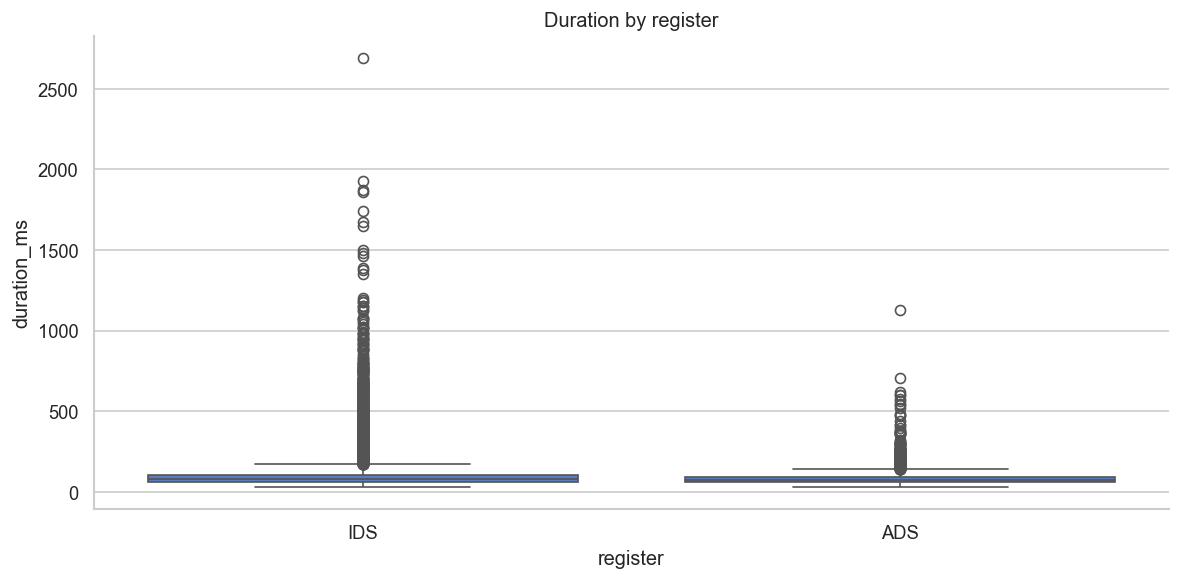

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\register_duration_boxplot.png


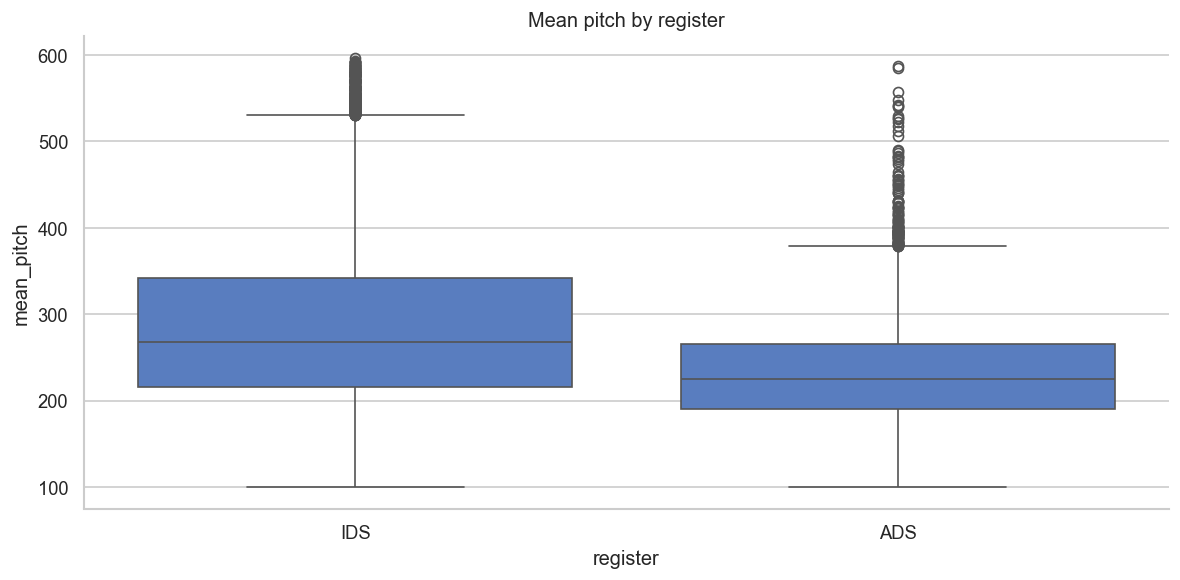

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\register_mean_pitch_boxplot.png


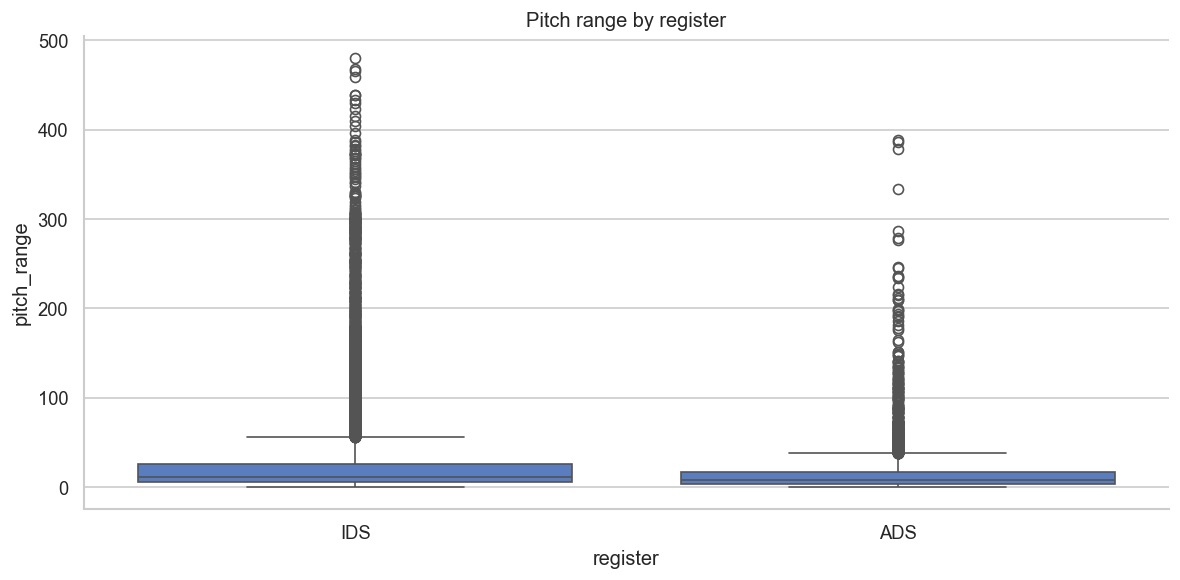

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\register_pitch_range_boxplot.png


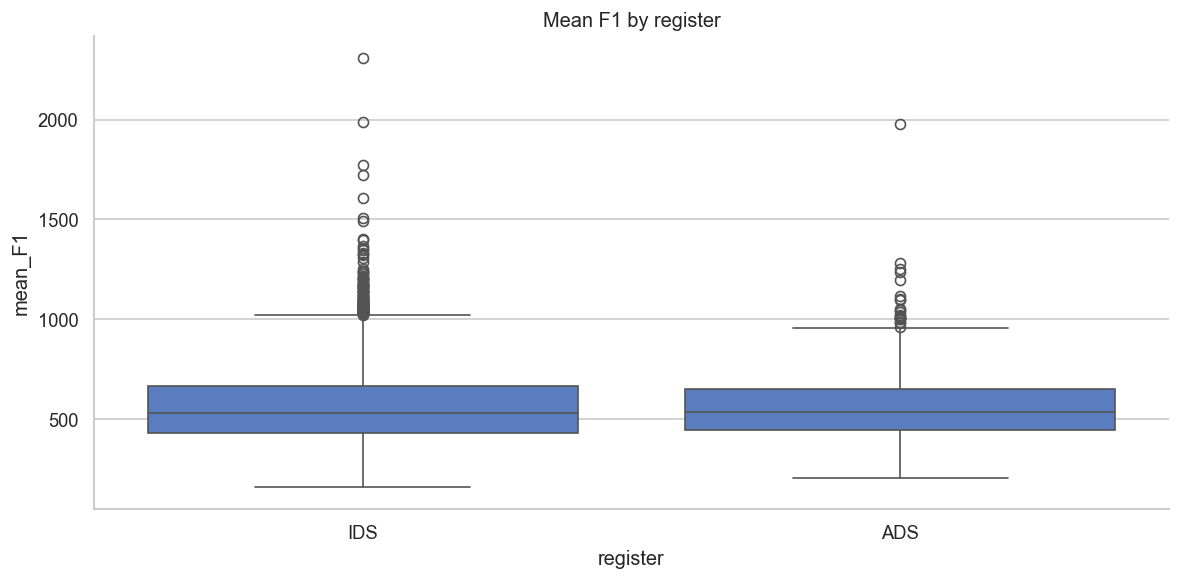

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\register_mean_F1_boxplot.png


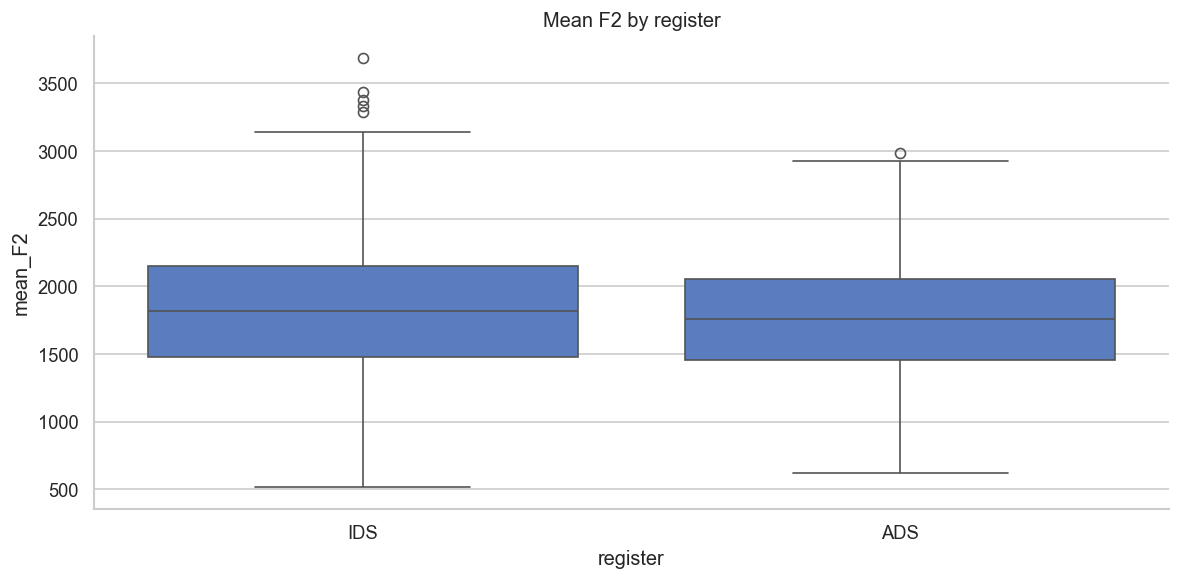

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\register_mean_F2_boxplot.png


In [9]:
register_summary = qc_df.groupby('register', dropna=False).apply(
    lambda g: pd.Series({
        'n_tokens': len(g),
        'n_success': int(g['feature_status'].eq('success').sum()),
        'n_failed': int(g['feature_status'].eq('failed').sum()),
        'success_rate': float(g['feature_status'].eq('success').mean() * 100),
        'mean_duration_ms': float(g['duration_ms'].mean()),
        'mean_pitch': float(g['mean_pitch'].mean()),
        'mean_pitch_range': float(g['pitch_range'].mean()),
        'mean_F1': float(g['mean_F1'].mean()),
        'mean_F2': float(g['mean_F2'].mean()),
        'central_F1': float(g['central_F1'].mean()),
        'central_F2': float(g['central_F2'].mean()),
    })
).reset_index()
save_table(register_summary, 'register_summary.csv')
print(register_summary)

plot_box(success_df, 'register', 'duration_ms', 'Duration by register', 'register_duration_boxplot.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'mean_pitch', 'Mean pitch by register', 'register_mean_pitch_boxplot.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'pitch_range', 'Pitch range by register', 'register_pitch_range_boxplot.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'mean_F1', 'Mean F1 by register', 'register_mean_F1_boxplot.png', order=REGISTER_ORDER, rotate=0)
plot_box(success_df, 'register', 'mean_F2', 'Mean F2 by register', 'register_mean_F2_boxplot.png', order=REGISTER_ORDER, rotate=0)


## 10. Vowel-level summary

Compute per-vowel token counts, success rates, durations, pitch, formants, and missingness percentages.

In [10]:
vowel_summary = qc_df.groupby('vowel', dropna=False).apply(
    lambda g: pd.Series({
        'n_tokens': len(g),
        'n_success': int(g['feature_status'].eq('success').sum()),
        'n_failed': int(g['feature_status'].eq('failed').sum()),
        'success_rate': float(g['feature_status'].eq('success').mean() * 100),
        'mean_duration_ms': float(g['duration_ms'].mean()),
        'median_duration_ms': float(g['duration_ms'].median()),
        'mean_pitch': float(g['mean_pitch'].mean()),
        'median_pitch': float(g['mean_pitch'].median()),
        'mean_pitch_range': float(g['pitch_range'].mean()),
        'median_pitch_range': float(g['pitch_range'].median()),
        'mean_F1': float(g['mean_F1'].mean()),
        'mean_F2': float(g['mean_F2'].mean()),
        'mean_F3': float(g['mean_F3'].mean()),
        'mean_F4': float(g['mean_F4'].mean()),
        'central_F1': float(g['central_F1'].mean()),
        'central_F2': float(g['central_F2'].mean()),
        'central_F3': float(g['central_F3'].mean()),
        'central_F4': float(g['central_F4'].mean()),
        'missing_pitch_percentage': float(g['mean_pitch'].isna().mean() * 100),
        'missing_formant_percentage': float(g[FORMANT_COLS].isna().any(axis=1).mean() * 100),
    })
).reset_index()
save_table(vowel_summary, 'vowel_summary.csv')
print(vowel_summary.sort_values('n_tokens', ascending=False))


Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\vowel_summary.csv
       vowel  n_tokens  n_success  n_failed  success_rate  mean_duration_ms  median_duration_ms  mean_pitch  \
0          a    5164.0     5067.0      97.0     98.121611         94.127432              78.045  261.495166   
4          e    2672.0     2650.0      22.0     99.176647         94.675262              74.885  272.632897   
7          i    2031.0     2013.0      18.0     99.113737        105.894077              77.930  296.744305   
1         ai    1886.0     1870.0      16.0     99.151644         97.538378              73.415  260.478527   
11        oe    1376.0     1360.0      16.0     98.837209         89.777863              69.745  269.693844   
12        on    1368.0     1357.0      11.0     99.195906        108.425058              86.375  281.977565   
14        ou    1357.0     1346.0      11.0     99.189388        124.460273              85.150 

## 11. Speaker-level QC

Summarize success rates, failures, pitch/formant means, and common errors by speaker.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\speaker_qc_summary.csv
   speakerid  n_tokens  n_success  n_failed  success_rate  failure_rate  mean_duration_ms  mean_pitch  \
3       c018      3713       3704         9     99.757608      0.242392         91.649480  327.081369   
4       c021      1155       1011       144     87.532468     12.467532         90.941385  255.232697   
2       c012       910        900        10     98.901099      1.098901        136.090110  272.049323   
16      c053       876        867         9     98.972603      1.027397         91.672842  236.599071   
25      c069       869        869         0    100.000000      0.000000        109.226421  277.829842   
18      c056       830        826         4     99.518072      0.481928        102.811036  250.055984   
7       c028       830        825         5     99.397590      0.602410         99.768205  311.518865   
9       c035       798      

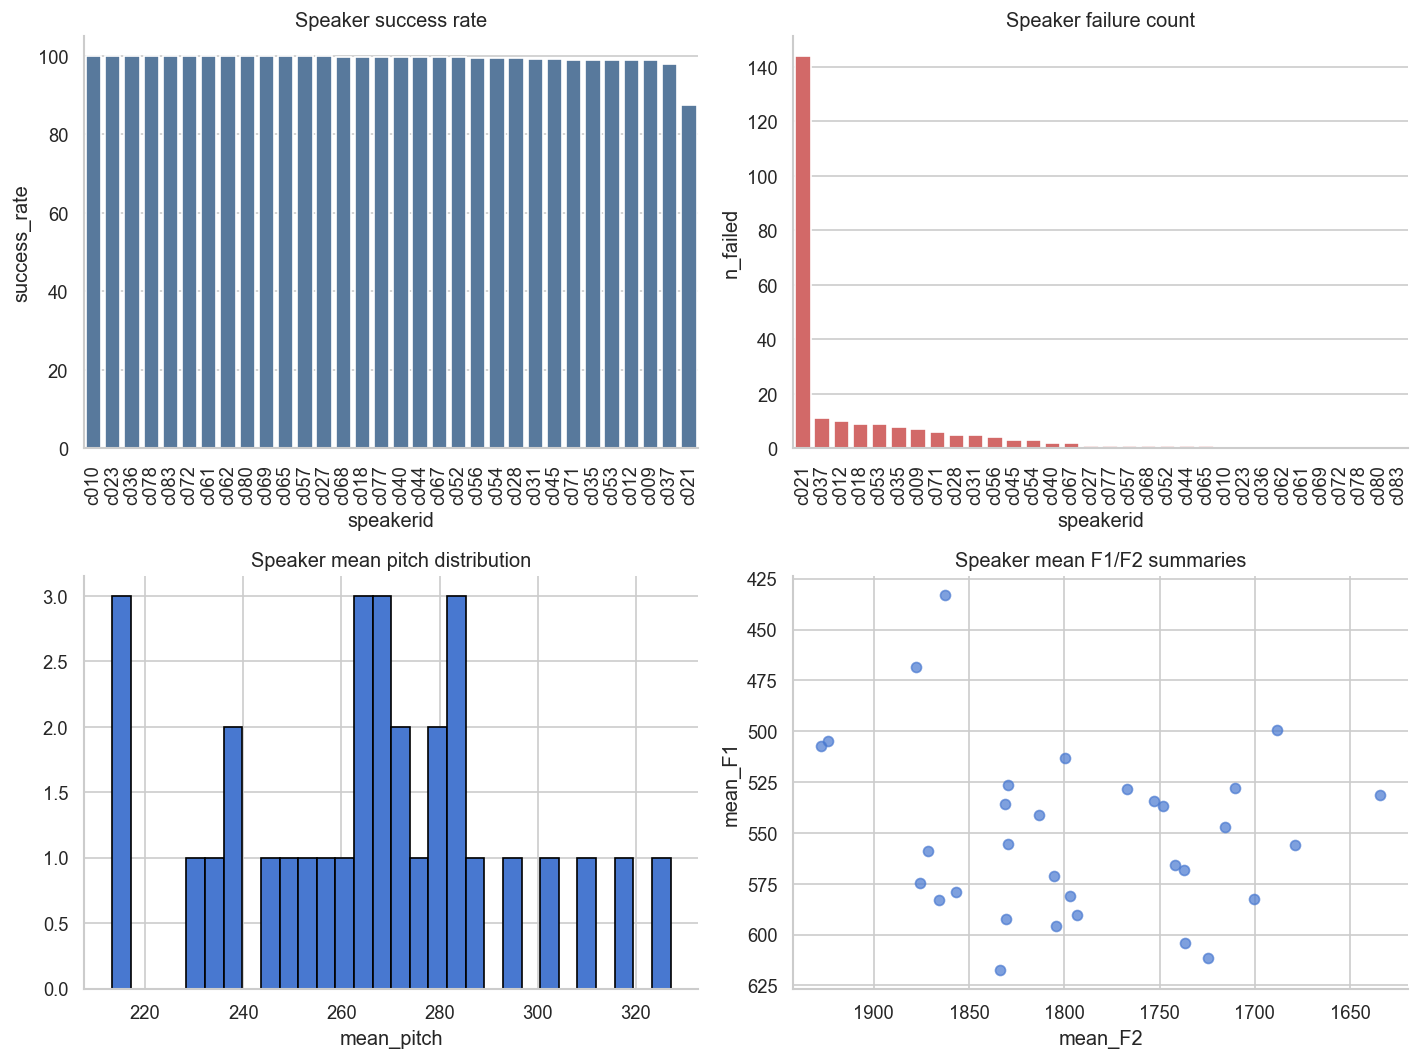

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\speaker_qc_plots.png


In [11]:
def mode_or_empty(series: pd.Series) -> str:
    cleaned = series.fillna('').replace('', np.nan).dropna()
    if cleaned.empty:
        return ''
    return str(cleaned.mode().iloc[0])

speaker_summary = qc_df.groupby('speakerid', dropna=False).apply(
    lambda g: pd.Series({
        'n_tokens': len(g),
        'n_success': int(g['feature_status'].eq('success').sum()),
        'n_failed': int(g['feature_status'].eq('failed').sum()),
        'success_rate': float(g['feature_status'].eq('success').mean() * 100),
        'failure_rate': float(g['feature_status'].eq('failed').mean() * 100),
        'mean_duration_ms': float(g['duration_ms'].mean()),
        'mean_pitch': float(g['mean_pitch'].mean()),
        'mean_pitch_range': float(g['pitch_range'].mean()),
        'mean_F1': float(g['mean_F1'].mean()),
        'mean_F2': float(g['mean_F2'].mean()),
        'central_F1': float(g['central_F1'].mean()),
        'central_F2': float(g['central_F2'].mean()),
        'number_of_missing_files': int(g['feature_error'].eq('audio_file_missing').sum()),
        'most_common_feature_error': mode_or_empty(g['feature_error']),
    })
).reset_index()
save_table(speaker_summary, 'speaker_qc_summary.csv')
print(speaker_summary.sort_values('n_tokens', ascending=False).head(20))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
speaker_order = speaker_summary.sort_values('success_rate', ascending=False)['speakerid']
sns.barplot(data=speaker_summary.sort_values('success_rate', ascending=False), x='speakerid', y='success_rate', ax=axes[0, 0], color='#4C78A8')
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].set_title('Speaker success rate')
sns.barplot(data=speaker_summary.sort_values('n_failed', ascending=False), x='speakerid', y='n_failed', ax=axes[0, 1], color='#E45756')
axes[0, 1].tick_params(axis='x', rotation=90)
axes[0, 1].set_title('Speaker failure count')
axes[1, 0].hist(speaker_summary['mean_pitch'].dropna(), bins=30, edgecolor='black')
axes[1, 0].set_title('Speaker mean pitch distribution')
axes[1, 0].set_xlabel('mean_pitch')
axes[1, 1].scatter(speaker_summary['mean_F2'], speaker_summary['mean_F1'], alpha=0.7)
axes[1, 1].invert_xaxis()
axes[1, 1].invert_yaxis()
axes[1, 1].set_title('Speaker mean F1/F2 summaries')
axes[1, 1].set_xlabel('mean_F2')
axes[1, 1].set_ylabel('mean_F1')
finish_plot(fig, 'speaker_qc_plots.png')


## 12. Error analysis

Use the acoustic audit log and merged QC frame to inspect error counts, speaker- and vowel-level patterns, and duration dependence.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\error_by_speaker.csv
Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\error_by_vowel.csv
Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\error_by_register.csv
Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\error_by_activity.csv


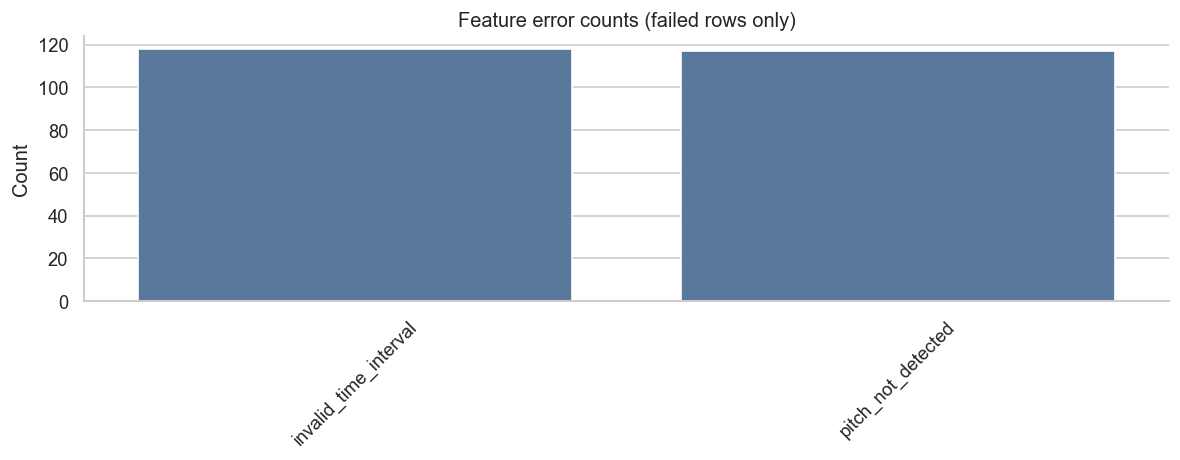

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\error_counts_failed_only.png


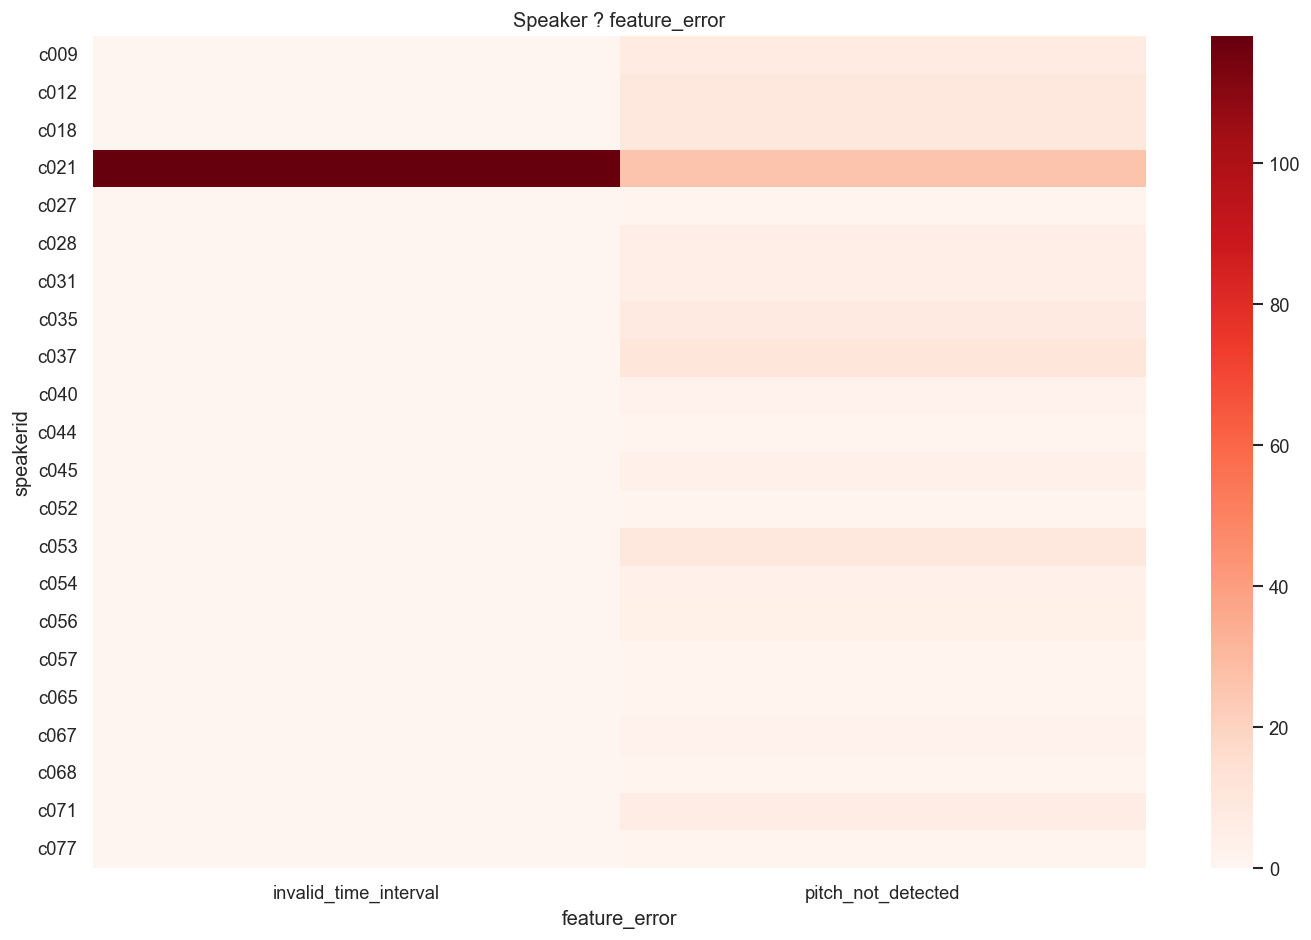

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\speaker_error_heatmap.png


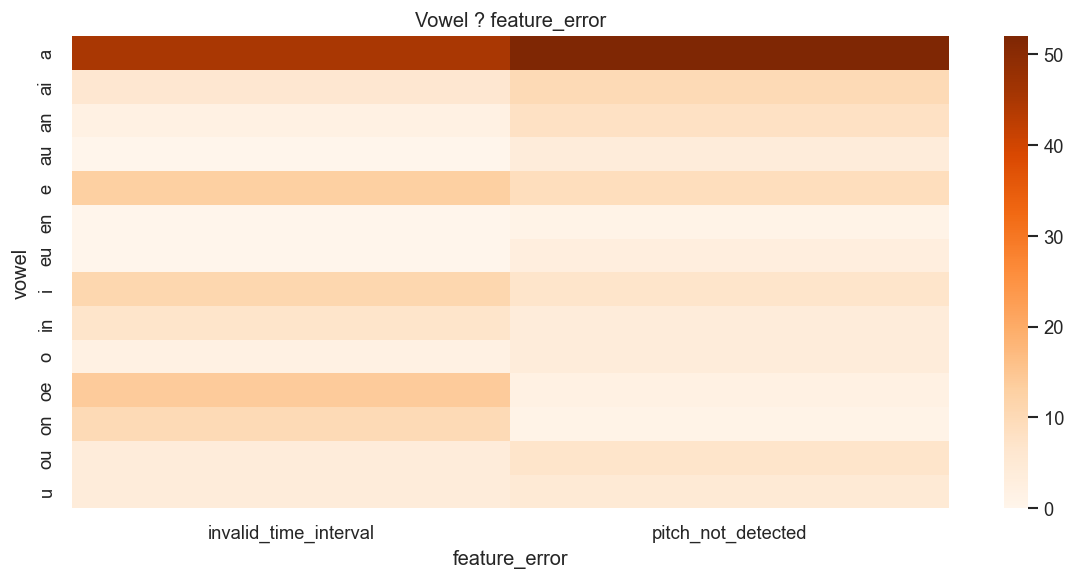

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\vowel_error_heatmap.png


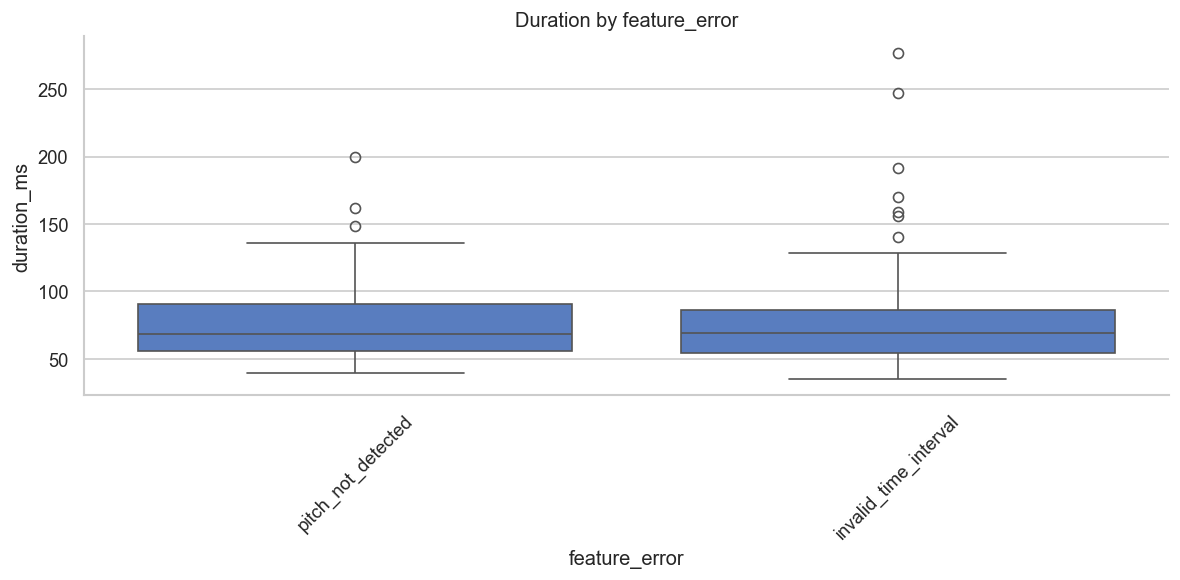

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\duration_by_feature_error.png
feature_error
invalid_time_interval    118
pitch_not_detected       117
Name: count, dtype: int64

feature_error by register:
  register          feature_error  n_rows
0      IDS  invalid_time_interval       7
1      IDS     pitch_not_detected      88
2      ADS  invalid_time_interval     111
3      ADS     pitch_not_detected      29

feature_error by activity:
  activity          feature_error  n_rows
0     bath     pitch_not_detected      44
1     meal  invalid_time_interval     118
2     meal     pitch_not_detected      55
3     play     pitch_not_detected      18

feature_error by duration bin:
  duration_bin          feature_error  n_rows
0          <50  invalid_time_interval      20
1          <50     pitch_not_detected      10
2        50-99  invalid_time_interval      78
3        50-99     pitch_not_detected      83
4      100-149  inva

In [12]:
error_df = qc_df[qc_df['feature_error'].fillna('').ne('')].copy()
error_df['duration_bin'] = pd.cut(error_df['duration_ms'], bins=[0, 50, 100, 150, 250, np.inf], labels=['<50', '50-99', '100-149', '150-249', '250+'], right=False)

error_by_speaker = error_df.groupby(['speakerid', 'feature_error'], dropna=False).size().reset_index(name='n_rows')
error_by_vowel = error_df.groupby(['vowel', 'feature_error'], dropna=False).size().reset_index(name='n_rows')
error_by_register = error_df.groupby(['register', 'feature_error'], dropna=False).size().reset_index(name='n_rows')
error_by_activity = error_df.groupby(['activity', 'feature_error'], dropna=False).size().reset_index(name='n_rows')

save_table(error_by_speaker, 'error_by_speaker.csv')
save_table(error_by_vowel, 'error_by_vowel.csv')
save_table(error_by_register, 'error_by_register.csv')
save_table(error_by_activity, 'error_by_activity.csv')

plot_count(error_df['feature_error'], 'Feature error counts (failed rows only)', 'error_counts_failed_only.png', max_n=15)

speaker_heatmap = error_by_speaker.pivot(index='speakerid', columns='feature_error', values='n_rows').fillna(0)
if not speaker_heatmap.empty:
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(speaker_heatmap, cmap='Reds', ax=ax)
    ax.set_title('Speaker ? feature_error')
    finish_plot(fig, 'speaker_error_heatmap.png')

vowel_heatmap = error_by_vowel.pivot(index='vowel', columns='feature_error', values='n_rows').fillna(0)
if not vowel_heatmap.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(vowel_heatmap, cmap='Oranges', ax=ax)
    ax.set_title('Vowel ? feature_error')
    finish_plot(fig, 'vowel_error_heatmap.png')

if not error_df.empty:
    top_errors = top_categories(error_df['feature_error'], max_n=10)
    plot_box(error_df[error_df['feature_error'].isin(top_errors)], 'feature_error', 'duration_ms', 'Duration by feature_error', 'duration_by_feature_error.png', rotate=45)

print(error_df['feature_error'].value_counts())
print('\nfeature_error by register:')
print(error_by_register)
print('\nfeature_error by activity:')
print(error_by_activity)
print('\nfeature_error by duration bin:')
print(error_df.groupby(['duration_bin', 'feature_error'], dropna=False).size().reset_index(name='n_rows').head(20))


## 13. Missingness analysis

Inspect acoustic missingness overall and by speaker, vowel, and register.

In [13]:
missingness_summary = pd.DataFrame({
    'feature': ['mean_pitch', 'min_pitch', 'max_pitch', 'pitch_range', 'formant_ceiling'] + FORMANT_COLS,
})
missingness_summary['n_missing'] = missingness_summary['feature'].map(lambda c: int(qc_df[c].isna().sum()))
missingness_summary['missing_percentage'] = missingness_summary['feature'].map(lambda c: float(qc_df[c].isna().mean() * 100))
save_table(missingness_summary, 'missingness_summary.csv')
print(missingness_summary)

missing_by_speaker = qc_df.groupby('speakerid', dropna=False)[PITCH_COLS + FORMANT_COLS].apply(lambda g: g.isna().mean() * 100)
missing_by_vowel = qc_df.groupby('vowel', dropna=False)[PITCH_COLS + FORMANT_COLS].apply(lambda g: g.isna().mean() * 100)
missing_by_register = qc_df.groupby('register', dropna=False)[PITCH_COLS + FORMANT_COLS].apply(lambda g: g.isna().mean() * 100)

print('\nMissingness by speakerid (head):')
print(missing_by_speaker.head())
print('\nMissingness by vowel:')
print(missing_by_vowel)
print('\nMissingness by register:')
print(missing_by_register)


Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\missingness_summary.csv
            feature  n_missing  missing_percentage
0        mean_pitch        235            1.101167
1         min_pitch        235            1.101167
2         max_pitch        235            1.101167
3       pitch_range        235            1.101167
4   formant_ceiling        235            1.101167
5           mean_F1        235            1.101167
6           mean_F2        235            1.101167
7           mean_F3        235            1.101167
8           mean_F4        235            1.101167
9        central_F1        235            1.101167
10       central_F2        235            1.101167
11       central_F3        235            1.101167
12       central_F4        283            1.326086

Missingness by speakerid (head):
           mean_pitch  min_pitch  max_pitch  pitch_range    mean_F1    mean_F2    mean_F3    mean_F4  central_F1  \
spe

## 14. Outlier and sanity checks

Create a suspicious rows table using practical pitch and formant thresholds and summarize the main reasons.

In [14]:
def suspicious_reasons(row: pd.Series) -> str:
    reasons = []
    if pd.notna(row['mean_pitch']) and row['mean_pitch'] > 600:
        reasons.append('mean_pitch_gt_600')
    if pd.notna(row['min_pitch']) and row['min_pitch'] > 700:
        reasons.append('min_pitch_gt_700')
    if pd.notna(row['pitch_range']) and row['pitch_range'] > 500:
        reasons.append('pitch_range_gt_500')
    if pd.notna(row['mean_F1']) and row['mean_F1'] > 1500:
        reasons.append('mean_F1_gt_1500')
    if pd.notna(row['mean_F2']) and row['mean_F2'] > 4000:
        reasons.append('mean_F2_gt_4000')
    if pd.notna(row['mean_F2']) and row['mean_F2'] < 1000:
        reasons.append('mean_F2_lt_1000')
    if pd.notna(row['mean_F3']) and row['mean_F3'] > 5000:
        reasons.append('mean_F3_gt_5000')
    if pd.notna(row['mean_F4']) and row['mean_F4'] > 6000:
        reasons.append('mean_F4_gt_6000')
    return ';'.join(reasons)

suspicious_df = qc_df.copy()
suspicious_df['suspicious_reason'] = suspicious_df.apply(suspicious_reasons, axis=1)
suspicious_df = suspicious_df[suspicious_df['suspicious_reason'].ne('')].copy()
save_table(suspicious_df, 'suspicious_acoustic_rows.csv')

print(f'Number of suspicious rows: {len(suspicious_df)}')
if not suspicious_df.empty:
    suspicious_reason_counts = suspicious_df['suspicious_reason'].str.get_dummies(sep=';').sum().sort_values(ascending=False)
    print('\nSuspicious rows by reason:')
    print(suspicious_reason_counts)
    print('\nSuspicious rows by speakerid:')
    print(suspicious_df['speakerid'].value_counts().head(20))
    print('\nSuspicious rows by vowel:')
    print(suspicious_df['vowel'].value_counts())


Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\suspicious_acoustic_rows.csv
Number of suspicious rows: 844

Suspicious rows by reason:
mean_F2_lt_1000    837
mean_F1_gt_1500      7
dtype: int64

Suspicious rows by speakerid:
speakerid
c018    167
c053     64
c069     49
c037     41
c056     38
c028     37
c067     36
c040     35
c021     34
c009     33
c012     30
c031     30
c065     24
c072     23
c068     22
c057     21
c035     19
c071     19
c054     14
c083     14
Name: count, dtype: int64

Suspicious rows by vowel:
vowel
on    294
ou    182
o     138
an    123
au     33
a      28
oe     15
in     15
e       5
ai      4
i       4
u       3
Name: count, dtype: int64


## 15. Formant ceiling QC

Keep ceiling checks short. Inspect ceiling distributions, optimization status, and fallback usage.

Saved table -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\formant_ceiling_summary.csv
   n_speaker_vowel_groups  fallback_percentage  mean_formant_ceiling  median_formant_ceiling  min_formant_ceiling  \
0                     422             1.658768           5320.663507                  5305.0               4400.0   

   max_formant_ceiling  
0               6600.0  

optimization_status counts:
optimization_status
optimized                  415
fallback_too_few_tokens      7
Name: count, dtype: int64

Ceiling by vowel:
  vowel  n_non_missing  n_missing  missing_pct       mean  median         std     min     p05     p25     p75     p95  \
0     a           32.0        0.0          0.0  5511.2500  5490.0  360.821196  4850.0  4987.5  5230.0  5807.5  5963.5   
1    ai           32.0        0.0          0.0  5639.6875  5545.0  426.784560  4870.0  4974.0  5417.5  5817.5  6497.5   
2    an           32.0        0.0          0.0  4950.3125  

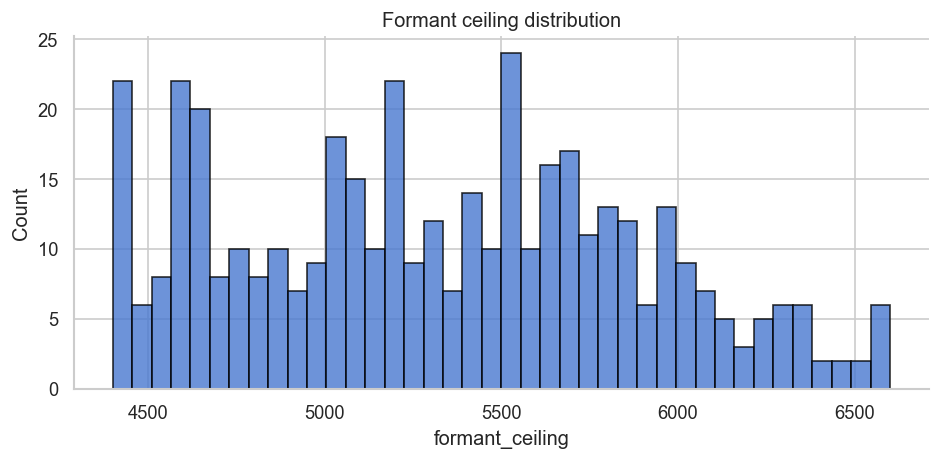

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\formant_ceiling_histogram.png


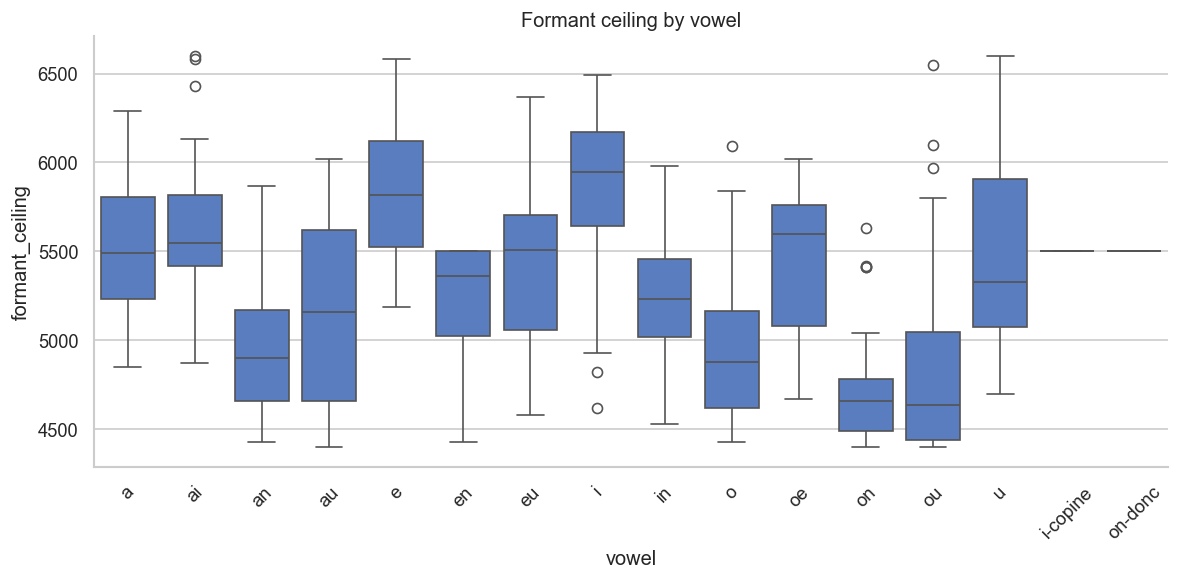

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\formant_ceiling_by_vowel.png


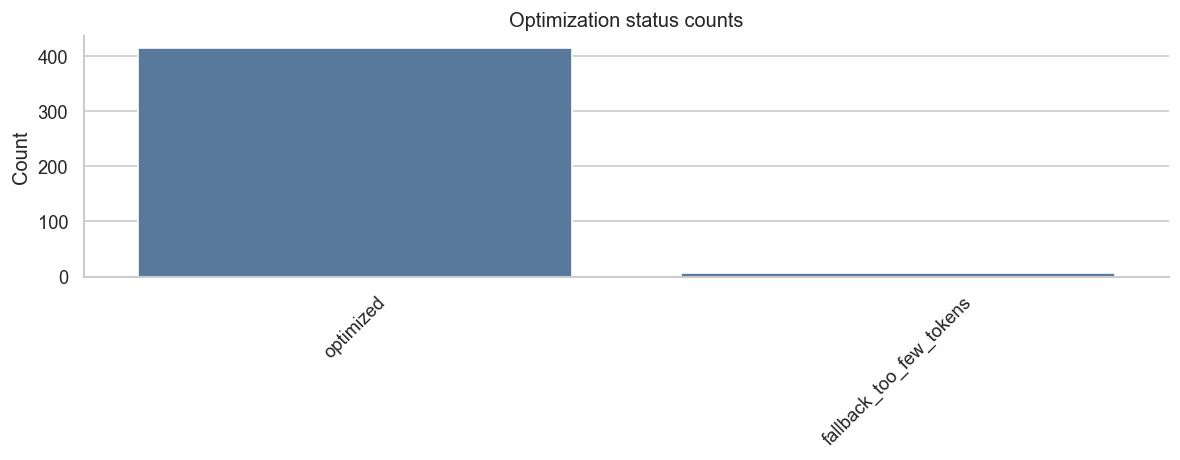

Saved plot -> C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots\optimization_status_counts.png


In [15]:
fallback_pct = float(ceilings_df['optimization_status'].fillna('').str.contains('fallback').mean() * 100)
formant_ceiling_summary = pd.DataFrame([
    {
        'n_speaker_vowel_groups': len(ceilings_df),
        'fallback_percentage': fallback_pct,
        'mean_formant_ceiling': float(ceilings_df['formant_ceiling'].mean()),
        'median_formant_ceiling': float(ceilings_df['formant_ceiling'].median()),
        'min_formant_ceiling': float(ceilings_df['formant_ceiling'].min()),
        'max_formant_ceiling': float(ceilings_df['formant_ceiling'].max()),
    }
])
save_table(formant_ceiling_summary, 'formant_ceiling_summary.csv')
print(formant_ceiling_summary)
print('\noptimization_status counts:')
print(ceilings_df['optimization_status'].value_counts())
print('\nCeiling by vowel:')
print(grouped_numeric_summary(ceilings_df, 'vowel', 'formant_ceiling').head())
print('\nCeiling by speakerid (head):')
print(grouped_numeric_summary(ceilings_df, 'speakerid', 'formant_ceiling').head(20))

plot_hist(ceilings_df, 'formant_ceiling', 'Formant ceiling distribution', 'formant_ceiling_histogram.png')
plot_box(ceilings_df, 'vowel', 'formant_ceiling', 'Formant ceiling by vowel', 'formant_ceiling_by_vowel.png', rotate=45)
plot_count(ceilings_df['optimization_status'], 'Optimization status counts', 'optimization_status_counts.png')


## 16. Final QC report summary

Print a concise notebook summary highlighting the main success rates, common errors, suspicious rows, and the speakers and vowels that need follow-up.

In [16]:
error_counts = qc_df['feature_error'].replace('', '(none)').value_counts()
vowel_failure = qc_df.groupby('vowel', dropna=False)['feature_status'].apply(lambda s: s.eq('failed').mean() * 100).sort_values(ascending=False)
speaker_failure = qc_df.groupby('speakerid', dropna=False)['feature_status'].apply(lambda s: s.eq('failed').mean() * 100).sort_values(ascending=False)
missing_audio_rows = int(qc_df['feature_error'].eq('audio_file_missing').sum())
parselmouth_rows = int(qc_df['feature_error'].eq('parselmouth_error').sum())

pitch_reasonable = bool(success_df['mean_pitch'].dropna().between(75, 600).mean() >= 0.95) if success_df['mean_pitch'].notna().any() else False
formant_reasonable = bool(success_df['mean_F2'].dropna().between(1000, 4000).mean() >= 0.90) if success_df['mean_F2'].notna().any() else False

print('=== FINAL QC REPORT ===')
print(f'Total tokens: {len(qc_df):,}')
print(f'Success rate: {(qc_df["feature_status"].eq("success").mean() * 100):.2f}%')
print('Most common errors:')
print(error_counts.head(10))
print(f'Number of missing audio rows: {missing_audio_rows}')
print(f'Number of Parselmouth errors: {parselmouth_rows}')
print(f'Number of suspicious acoustic rows: {len(suspicious_df)}')
print('Vowels with highest failure rates:')
print(vowel_failure.head(10))
print('Speakers with highest failure rates:')
print(speaker_failure.head(10))
print(f'Pitch values look broadly reasonable: {pitch_reasonable}')
print(f'Formant values look broadly reasonable: {formant_reasonable}')


=== FINAL QC REPORT ===
Total tokens: 21,341
Success rate: 98.90%
Most common errors:
feature_error
(none)                   21106
invalid_time_interval      118
pitch_not_detected         117
Name: count, dtype: int64
Number of missing audio rows: 0
Number of Parselmouth errors: 0
Number of suspicious acoustic rows: 844
Vowels with highest failure rates:
vowel
en    6.666667
a     1.878389
oe    1.162791
in    1.148225
u     1.107011
i     0.886263
ai    0.848356
e     0.823353
ou    0.810612
on    0.804094
Name: feature_status, dtype: float64
Speakers with highest failure rates:
speakerid
c021    12.467532
c037     2.095238
c009     1.141925
c012     1.098901
c053     1.027397
c035     1.002506
c071     0.972447
c045     0.775194
c031     0.701262
c028     0.602410
Name: feature_status, dtype: float64
Pitch values look broadly reasonable: True
Formant values look broadly reasonable: True


## 17. Output organization

List the tables and plots generated by this notebook under `outputs/qc/` and `outputs/qc/plots/`.

In [17]:
print('QC directory:', QC_DIR)
print('Plots directory:', PLOTS_DIR)
print('\nSaved summary tables:')
for path in sorted(QC_DIR.glob('*.csv')):
    print(' -', path.name)
print('\nSaved plots:')
for path in sorted(PLOTS_DIR.glob('*.png')):
    print(' -', path.name)


QC directory: C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc
Plots directory: C:\Users\arunps\OneDrive\Projects\Scripts\Python\French_IDS_ADS_DayLong_recordings\outputs\qc\plots

Saved summary tables:
 - central_vs_mean_formants.csv
 - duration_summary.csv
 - error_by_activity.csv
 - error_by_register.csv
 - error_by_speaker.csv
 - error_by_vowel.csv
 - error_summary.csv
 - extraction_summary.csv
 - formant_ceiling_summary.csv
 - formant_summary.csv
 - missingness_summary.csv
 - pitch_summary.csv
 - register_summary.csv
 - speaker_qc_summary.csv
 - suspicious_acoustic_rows.csv
 - vowel_summary.csv

Saved plots:
 - central_F1_by_vowel.png
 - central_F1_histogram.png
 - central_F2_by_vowel.png
 - central_F2_histogram.png
 - duration_by_error.png
 - duration_by_feature_error.png
 - duration_by_register.png
 - duration_by_status.png
 - duration_by_vowel.png
 - duration_histogram.png
 - duration_vs_mean_pitch.png
 - duration_vs_pitch_range.png
